<a href="https://colab.research.google.com/github/gustkt/GE337_Programming_Dev/blob/main/Lab_3_%E0%B8%81%E0%B8%A4%E0%B8%95%E0%B8%A0%E0%B8%B2%E0%B8%AA_6606614615.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 3: การวิเคราะห์การเปลี่ยนแปลงพื้นที่สีเขียวโดยใช้ NDVI จากข้อมูลดาวเทียมหลายช่วงเวลา**

**ข้อมูลที่ใช้**

ข้อมูลเวกเตอร์ (Vector Data)


*   ขอบเขตพื้นที่ศึกษาจ.น่าน (Polygon)
*   ข้อมูลตำแหน่งของจุดตรวจวัด NDVI (จุด Hotspots ที่เกิดขึ้นในพื้นที่ป่า)

ข้อมูลแรสเตอร์ (Raster Data)


*   ภาพถ่ายดาวเทียม Sentinel-2 หรือ Landsat-8 สองช่วงเวลา (ปีปัจจุบันและปีก่อนหน้า)
*   Digital Elevation Model (DEM) เพื่อตรวจสอบความสัมพันธ์ของ NDVI
กับสภาพภูมิประเทศ

**การโหลดและเตรียมข้อมูล**

In [1]:
import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling

import numpy as np
import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

import folium
from pyproj import Transformer

* โหลดภาพถ่ายดาวเทียม 2 ช่วงเวลา และแสดง Metadata เช่น ค่า Resolution, CRS และ Bands ต่าง ๆ

In [2]:
img1_path = "/content/drive/MyDrive/Data for program dev/lab_3/Nan_S2/Nan_S2_01Dec24_01_Mar25.tif"
img2_path = "/content/drive/MyDrive/Data for program dev/lab_3/Nan_S2/Nan_S2_01Dec25_01_Mar26.tif"

src1 = rasterio.open(img1_path)
src2 = rasterio.open(img2_path)

print("img_1_Metadata:")
print("CRS:", src1.crs)
print("Resolution:", src1.res)
print("Bands:", src1.count)
print(src1.descriptions)

print("img_2_Metadata:")
print("CRS:", src2.crs)
print("Resolution:", src2.res)
print("Bands:", src2.count)
print(src2.descriptions)



img_1_Metadata:
CRS: EPSG:32647
Resolution: (10.0, 10.0)
Bands: 4
('B2', 'B3', 'B4', 'B8')
img_2_Metadata:
CRS: EPSG:32647
Resolution: (10.0, 10.0)
Bands: 4
('B2', 'B3', 'B4', 'B8')


* โหลดข้อมูลขอบเขตพื้นที่ศึกษาและจุดตรวจวัดจาก Shapefile หรือ GeoJSON

In [3]:
Nan_ROI = gpd.read_file("/content/drive/MyDrive/Data for program dev/lab_3/nan_bound/26_base2_nan.shp")
points = gpd.read_file("/content/drive/MyDrive/Data for program dev/lab_3/Nan_hotspots/Nan_Forest_Hotspot_1dec24_1march25.shp")

print("Nan_ROI CRS:", Nan_ROI.crs)
print("Points CRS:", points.crs)

Nan_ROI CRS: EPSG:4326
Points CRS: EPSG:4326


**การคำนวณ NDVI สำหรับแต่ละช่วงเวลา**

* แยก Band ที่จำเป็น (NIR และ Red) จากภาพถ่ายดาวเทียม

In [4]:
#แยก Band ภาพที่ 1
red1 = src1.read(3).astype(float) # Red = Band 4 ใน Sentinel-2 แต่อยู่ใน Band 3 ของไฟล์ภาพถ่ายดาวเทียม
nir1 = src1.read(4).astype(float) # NIR = Band 8 ใน Sentinel-2 แต่อยู่ใน Band 4 ของไฟล์ภาพถ่ายดาวเทียม

#แยก Band ภาพที่ 2
red2 = src2.read(3).astype(float) # Red = Band 4 ใน Sentinel-2 แต่อยู่ใน Band 3 ของไฟล์ภาพถ่ายดาวเทียม
nir2 = src2.read(4).astype(float) # NIR = Band 8 ใน Sentinel-2 แต่อยู่ใน Band 4 ของไฟล์ภาพถ่ายดาวเทียม

* คำนวณ NDVI

In [5]:
# ตรวจสอบ Nodata ก่อนคำนวณ NDVI
print("Image 1 band3 nodata:", src1.nodatavals[2]) # Index 2 = band 3 (ในไฟล์) = band 4 (Sentinel-2)
print("Image 1 band4 nodata:", src1.nodatavals[3]) # Index 3 = band 4 (ในไฟล์) = band 8 (Sentinel-2)
print("Image 2 band3 nodata:", src2.nodatavals[2])
print("Image 2 band4 nodata:", src2.nodatavals[3])

Image 1 band3 nodata: -inf
Image 1 band4 nodata: -inf
Image 2 band3 nodata: -inf
Image 2 band4 nodata: -inf


In [6]:
# แปลง -inf ให้เป็น Nan
red1[np.isneginf(red1)] = np.nan
nir1[np.isneginf(nir1)] = np.nan

red2[np.isneginf(red2)] = np.nan
nir2[np.isneginf(nir2)] = np.nan

In [7]:
# คำนวณ NDVI ภาพที่ 1
ndvi1 = (nir1 - red1) / (nir1 + red1 + 1e-10) # + 1e-10 เพื่อป้องกันการหารด้วยศูนย์

# คำนวณ NDVI ภาพที่ 2
ndvi2 = (nir2 - red2) / (nir2 + red2 + 1e-10) # + 1e-10 เพื่อป้องกันการหารด้วยศูนย์

* แสดงแผนที่ NDVI ของแต่ละช่วงเวลา

In [ ]:
plt.figure(figsize=(14,6))

# NDVI ภาพที่ 1
ax1 = plt.subplot(1,2,1)
img1 = ax1.imshow(ndvi1, cmap='RdYlGn', vmin=-1, vmax=1)
ax1.set_title("NDVI (Dec 2024 – Mar 2025)", fontsize=12)
ax1.axis('off')

cbar1 = plt.colorbar(img1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("NDVI")

# NDVI ภาพที่ 2
ax2 = plt.subplot(1,2,2)
img2 = ax2.imshow(ndvi2, cmap='RdYlGn', vmin=-1, vmax=1)
ax2.set_title("NDVI (Dec 2025 – Mar 2026)", fontsize=12)
ax2.axis('off')

cbar2 = plt.colorbar(img2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("NDVI")

plt.tight_layout()
plt.show()

เนื่องจากไม่สามารถ Run โค้ดนี้ได้ใน Google Colab ซึ่งเกิดจากการใช้ Ram เกินขีดจำกัดที่มีอยู่จึงได้แก้ไขโดยทำการ Run ผ่าน Jupyter lab ในโน้ตบุ๊คของตัวเอง และได้ผลลัพธ์ดังภาพ

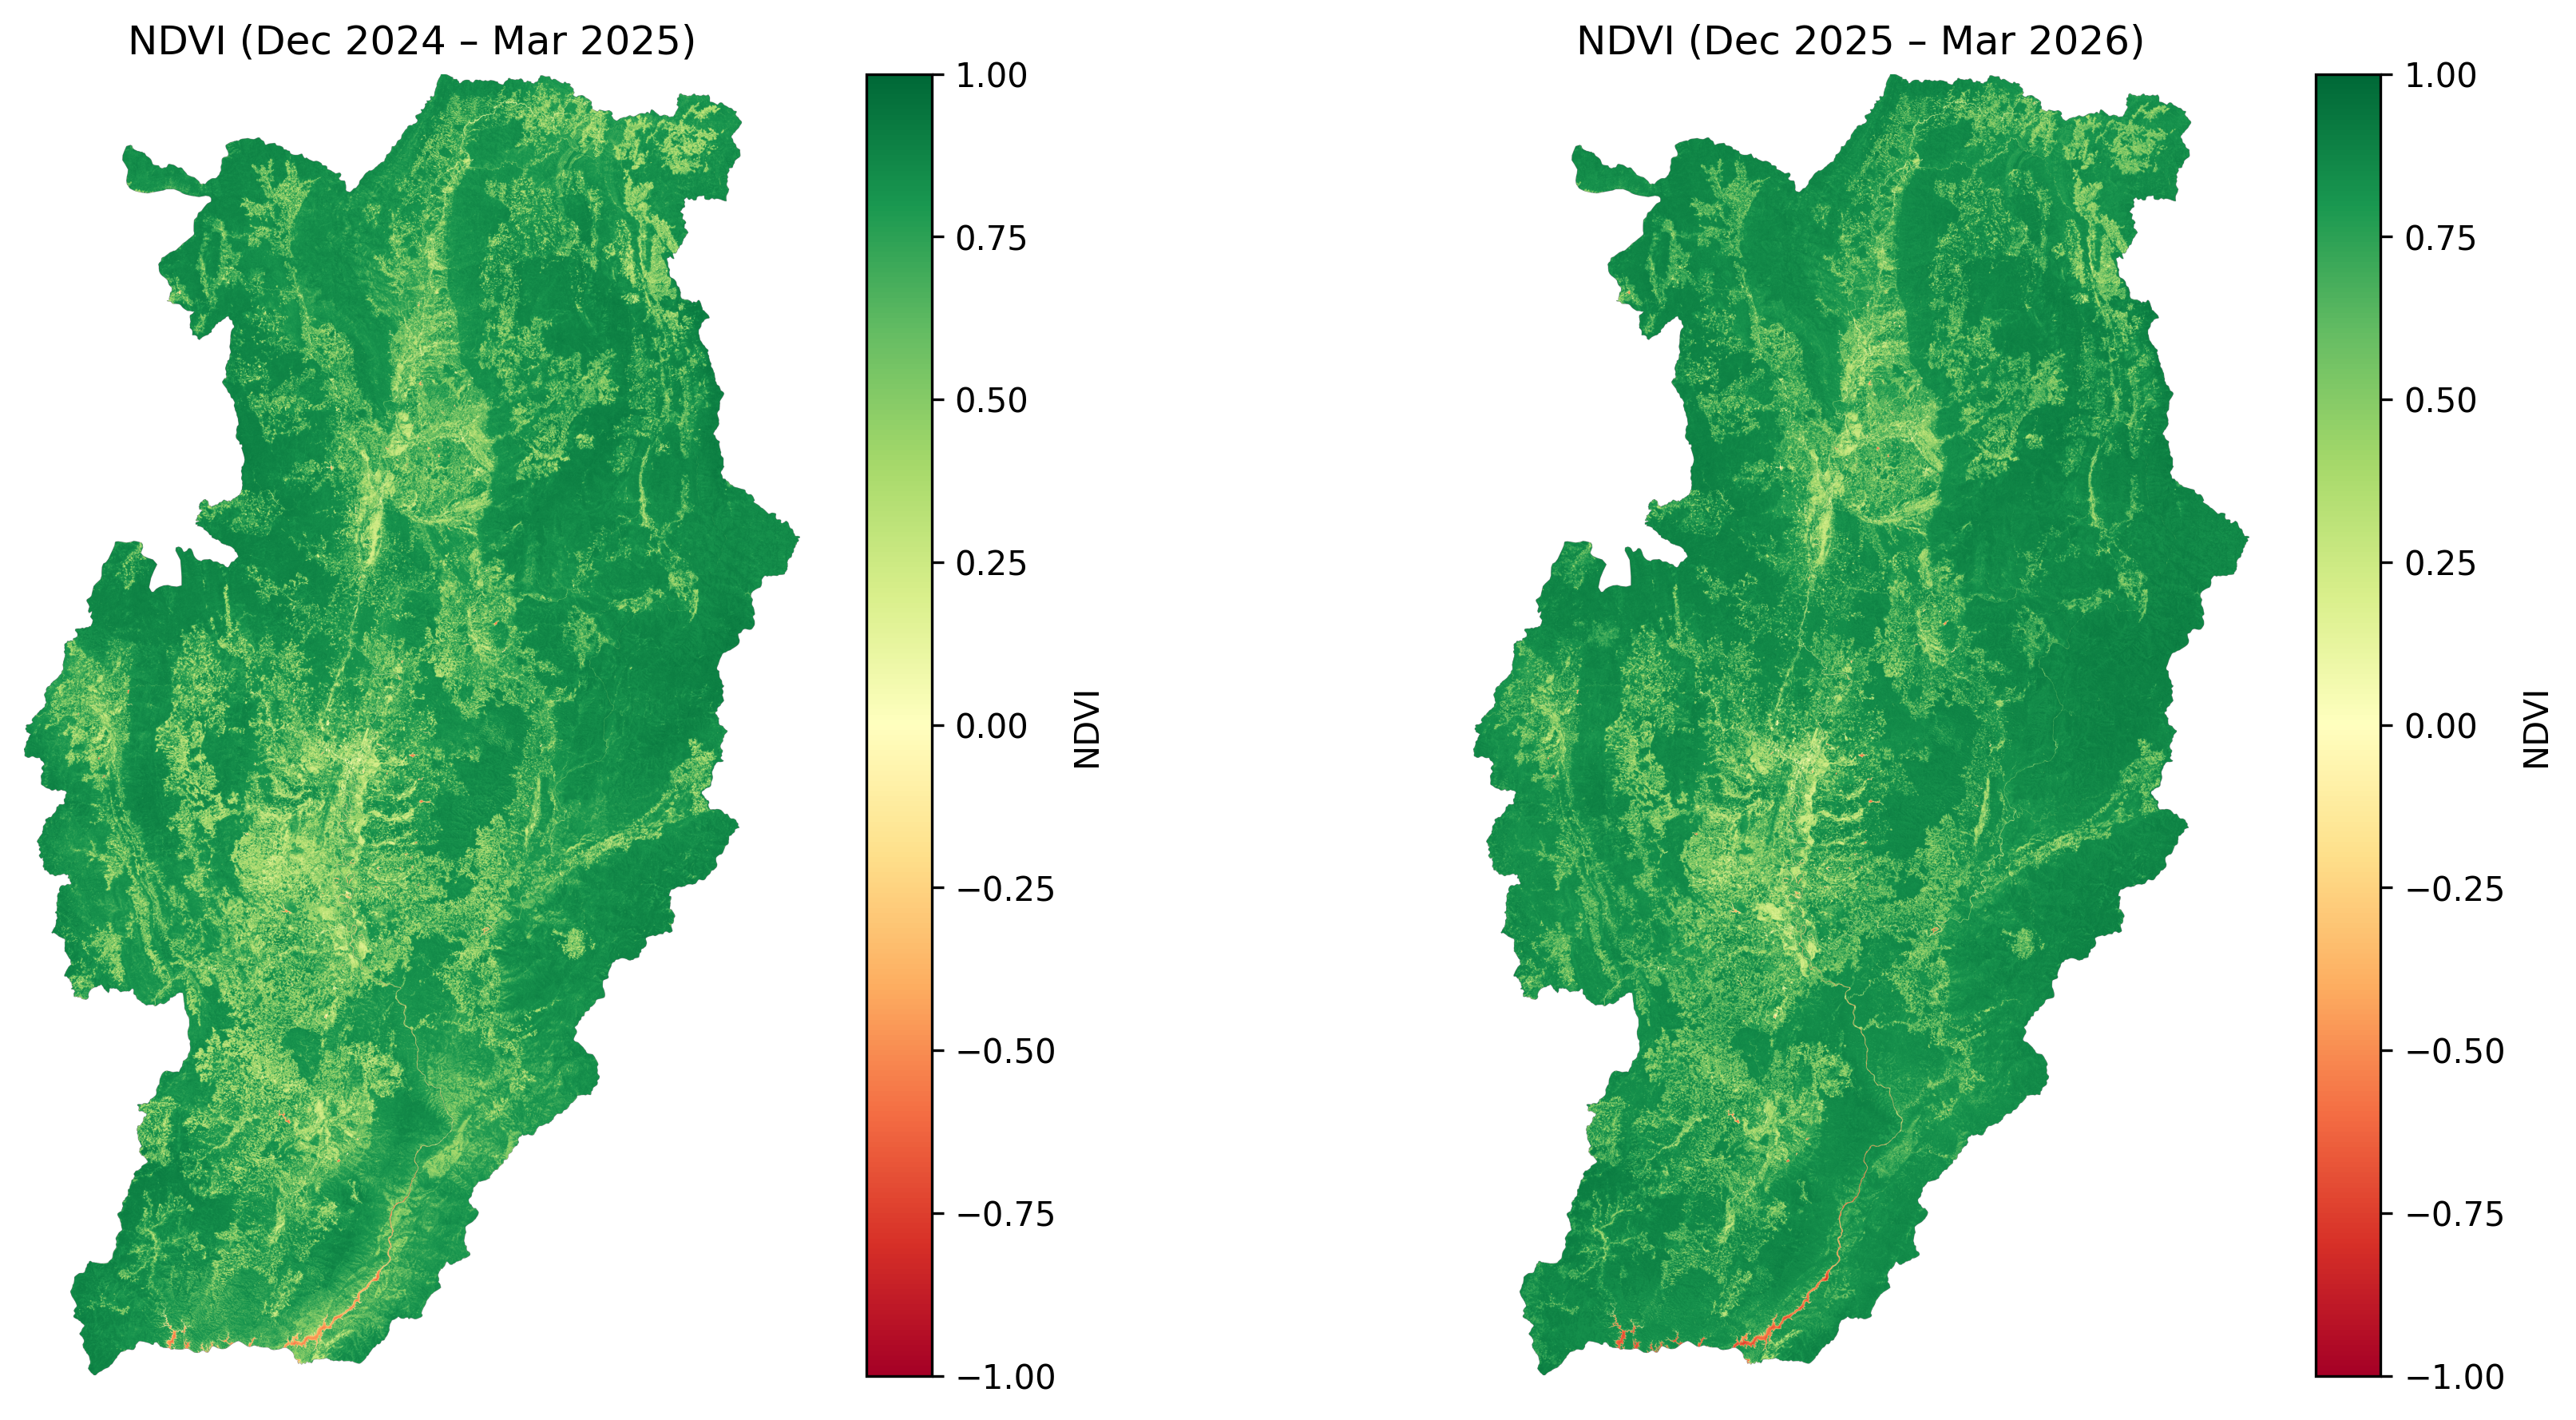

**การวิเคราะห์ความเปลี่ยนแปลงของ NDVI (Change Detection)**

* คำนวณ Difference NDVI ระหว่าง 2 ช่วงเวลา: ΔNDVI=NDVIปีปัจจุบัน−NDVIปีก่อน\Delta NDVI =
NDVI_{ปีปัจจุบัน} - NDVI_{ปีก่อน}

In [8]:
# คำนวณ Difference
delta_ndvi = ndvi2 - ndvi1

หลังจากโค้ดคำนวณ Difference NDVI จะไม่สามารถ Run ได้ใน Google Colab ทั้งหมด ซึ่งเกิดจากการใช้ Ram เกินขีดจำกัดที่มีอยู่จึงได้แก้ไขโดยทำการ Run ผ่าน Jupyter lab ในโน้ตบุ๊คของตัวเอง และนำผลลัพธ์มาแสดงเป็นข้อความ หรือรูปภาพตามความเหมาะสมของโค้ดนั้น ๆ ขออภัยในข้อผิดพลาดครับ

* กำหนด Threshold เพื่อตรวจจับพื้นที่ที่มีการเปลี่ยนแปลงอย่างชัดเจน (เช่น ป่าถูกตัด,
การขยายตัวของเมือง)

In [ ]:
threshold = 0.2

loss_mask = delta_ndvi < -threshold
gain_mask = delta_ndvi > threshold
stable_mask = np.abs(delta_ndvi) <= threshold

* แสดงแผนที่การเปลี่ยนแปลง NDVI โดยใช้ Matplotlib หรือ Folium หรือ GEEMAP

In [9]:
# ตรวจสอบ และดึงข้อมูลตำแหน่งของจุดตรวจวัด NDVI (จุด Hotspots ที่เกิดขึ้นในพื้นที่ป่า)
points = points.to_crs(src1.crs)
transform1 = src1.transform
coords = [(x,y) for x,y in zip(points.geometry.x, points.geometry.y)]

ndvi_point1 = []
ndvi_point2 = []
delta_point = []

rows, cols = ndvi1.shape

for x, y in coords:

    col, row = ~transform1 * (x, y)

    row = int(row)
    col = int(col)

    # ตรวจว่าจุดอยู่ใน raster
    if 0 <= row < rows and 0 <= col < cols:

        ndvi_point1.append(ndvi1[row, col])
        ndvi_point2.append(ndvi2[row, col])
        delta_point.append(delta_ndvi[row, col])

    else:
        ndvi_point1.append(np.nan)
        ndvi_point2.append(np.nan)
        delta_point.append(np.nan)

In [10]:
points["NDVI_2025"] = ndvi_point1
points["NDVI_2026"] = ndvi_point2
points["Delta_NDVI"] = delta_point

points.head()

,LATITUDE,LONGITUDE,UTM_X,UTM_Y,UTM_ZONE,SATELLITE,TUMBOON,AUMPER,PROVINCE,TYPE,NAME,FOREST,OWN,geometry,NDVI_2025,NDVI_2026,Delta_NDVI
0,19.53991,100.86535,695713,2161635,47N,S,งอบ,ทุ่งช้าง,น่าน,NRF,ป่าน้ำยาว และป่าน้ำสวด,Y,RFD,POINT (695713.031 2161634.878),0.771756,0.820315,0.048560
1,18.96542,100.73248,682403,2097898,47N,S,บ่อ,เมืองน่าน,น่าน,NRF,ป่าน้ำยาว และป่าน้ำสวด,Y,RFD,POINT (682403.04 2097897.698),0.841141,0.881101,0.039960
2,18.97869,100.65912,674664,2099292,47N,S,บ่อ,เมืองน่าน,น่าน,NRF,ป่าน้ำยาว และป่าน้ำสวด,Y,RFD,POINT (674663.796 2099292.146),0.893602,0.881209,-0.012393
3,18.96591,100.68695,677608,2097905,47N,S,บ่อ,เมืองน่าน,น่าน,NRF,ป่าน้ำยาว และป่าน้ำสวด,Y,RFD,POINT (677607.809 2097905.421),0.866051,0.872619,0.006568
4,19.45426,101.14653,725343,2152498,47N,S,ขุนน่าน,เฉลิมพระเกียรติ,น่าน,NRF,ป่าดอยภูคาและป่าผาแดง,Y,RFD,POINT (725343.224 2152497.888),0.768302,0.825538,0.057236


In [11]:
points[["LATITUDE", "LONGITUDE", "NAME", "TUMBOON", "AUMPER", "NDVI_2025","NDVI_2026","Delta_NDVI"]]

,LATITUDE,LONGITUDE,NAME,TUMBOON,AUMPER,NDVI_2025,NDVI_2026,Delta_NDVI
0,19.53991,100.86535,ป่าน้ำยาว และป่าน้ำสวด,งอบ,ทุ่งช้าง,0.771756,0.820315,0.048560
1,18.96542,100.73248,ป่าน้ำยาว และป่าน้ำสวด,บ่อ,เมืองน่าน,0.841141,0.881101,0.039960
2,18.97869,100.65912,ป่าน้ำยาว และป่าน้ำสวด,บ่อ,เมืองน่าน,0.893602,0.881209,-0.012393
3,18.96591,100.68695,ป่าน้ำยาว และป่าน้ำสวด,บ่อ,เมืองน่าน,0.866051,0.872619,0.006568
4,19.45426,101.14653,ป่าดอยภูคาและป่าผาแดง,ขุนน่าน,เฉลิมพระเกียรติ,0.768302,0.825538,0.057236
...,...,...,...,...,...,...,...,...
491,19.24842,100.86671,พื้นที่อื่น,เชียงคาน,เชียงกลาง,0.741503,0.744240,0.002736
492,19.25560,100.86925,พื้นที่อื่น,เชียงคาน,เชียงกลาง,0.748326,0.739414,-0.008912
493,19.56561,101.11115,ป่าดอยภูคาและป่าผาแดง,ห้วยโก๋น,เฉลิมพระเกียรติ,0.819989,0.845820,0.025831
494,19.26077,100.86906,พื้นที่อื่น,เชียงคาน,เชียงกลาง,0.765879,0.747696,-0.018184


In [ ]:
# สร้างแผนที่โดยใช้ Matplotlib

# ใช้ transform จากตอน crop
extent = (
    transform1[2],
    transform1[2] + delta_ndvi.shape[1] * transform1[0],
    transform1[5] + delta_ndvi.shape[0] * transform1[4],
    transform1[5]
)

# threshold
threshold = 0.2
change_map = np.zeros_like(delta_ndvi)
change_map[delta_ndvi <= -threshold] = -1
change_map[delta_ndvi >= threshold] = 1

cmap = ListedColormap(["red", "white", "green"])

plt.figure(figsize=(10,8), dpi=300)

plt.imshow(
    change_map,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    extent=extent,
    interpolation="none"
)

plt.title("Nan NDVI Change (2026-2025)")
plt.xlabel("Easting")
plt.ylabel("Northing")

plt.colorbar()
plt.show()

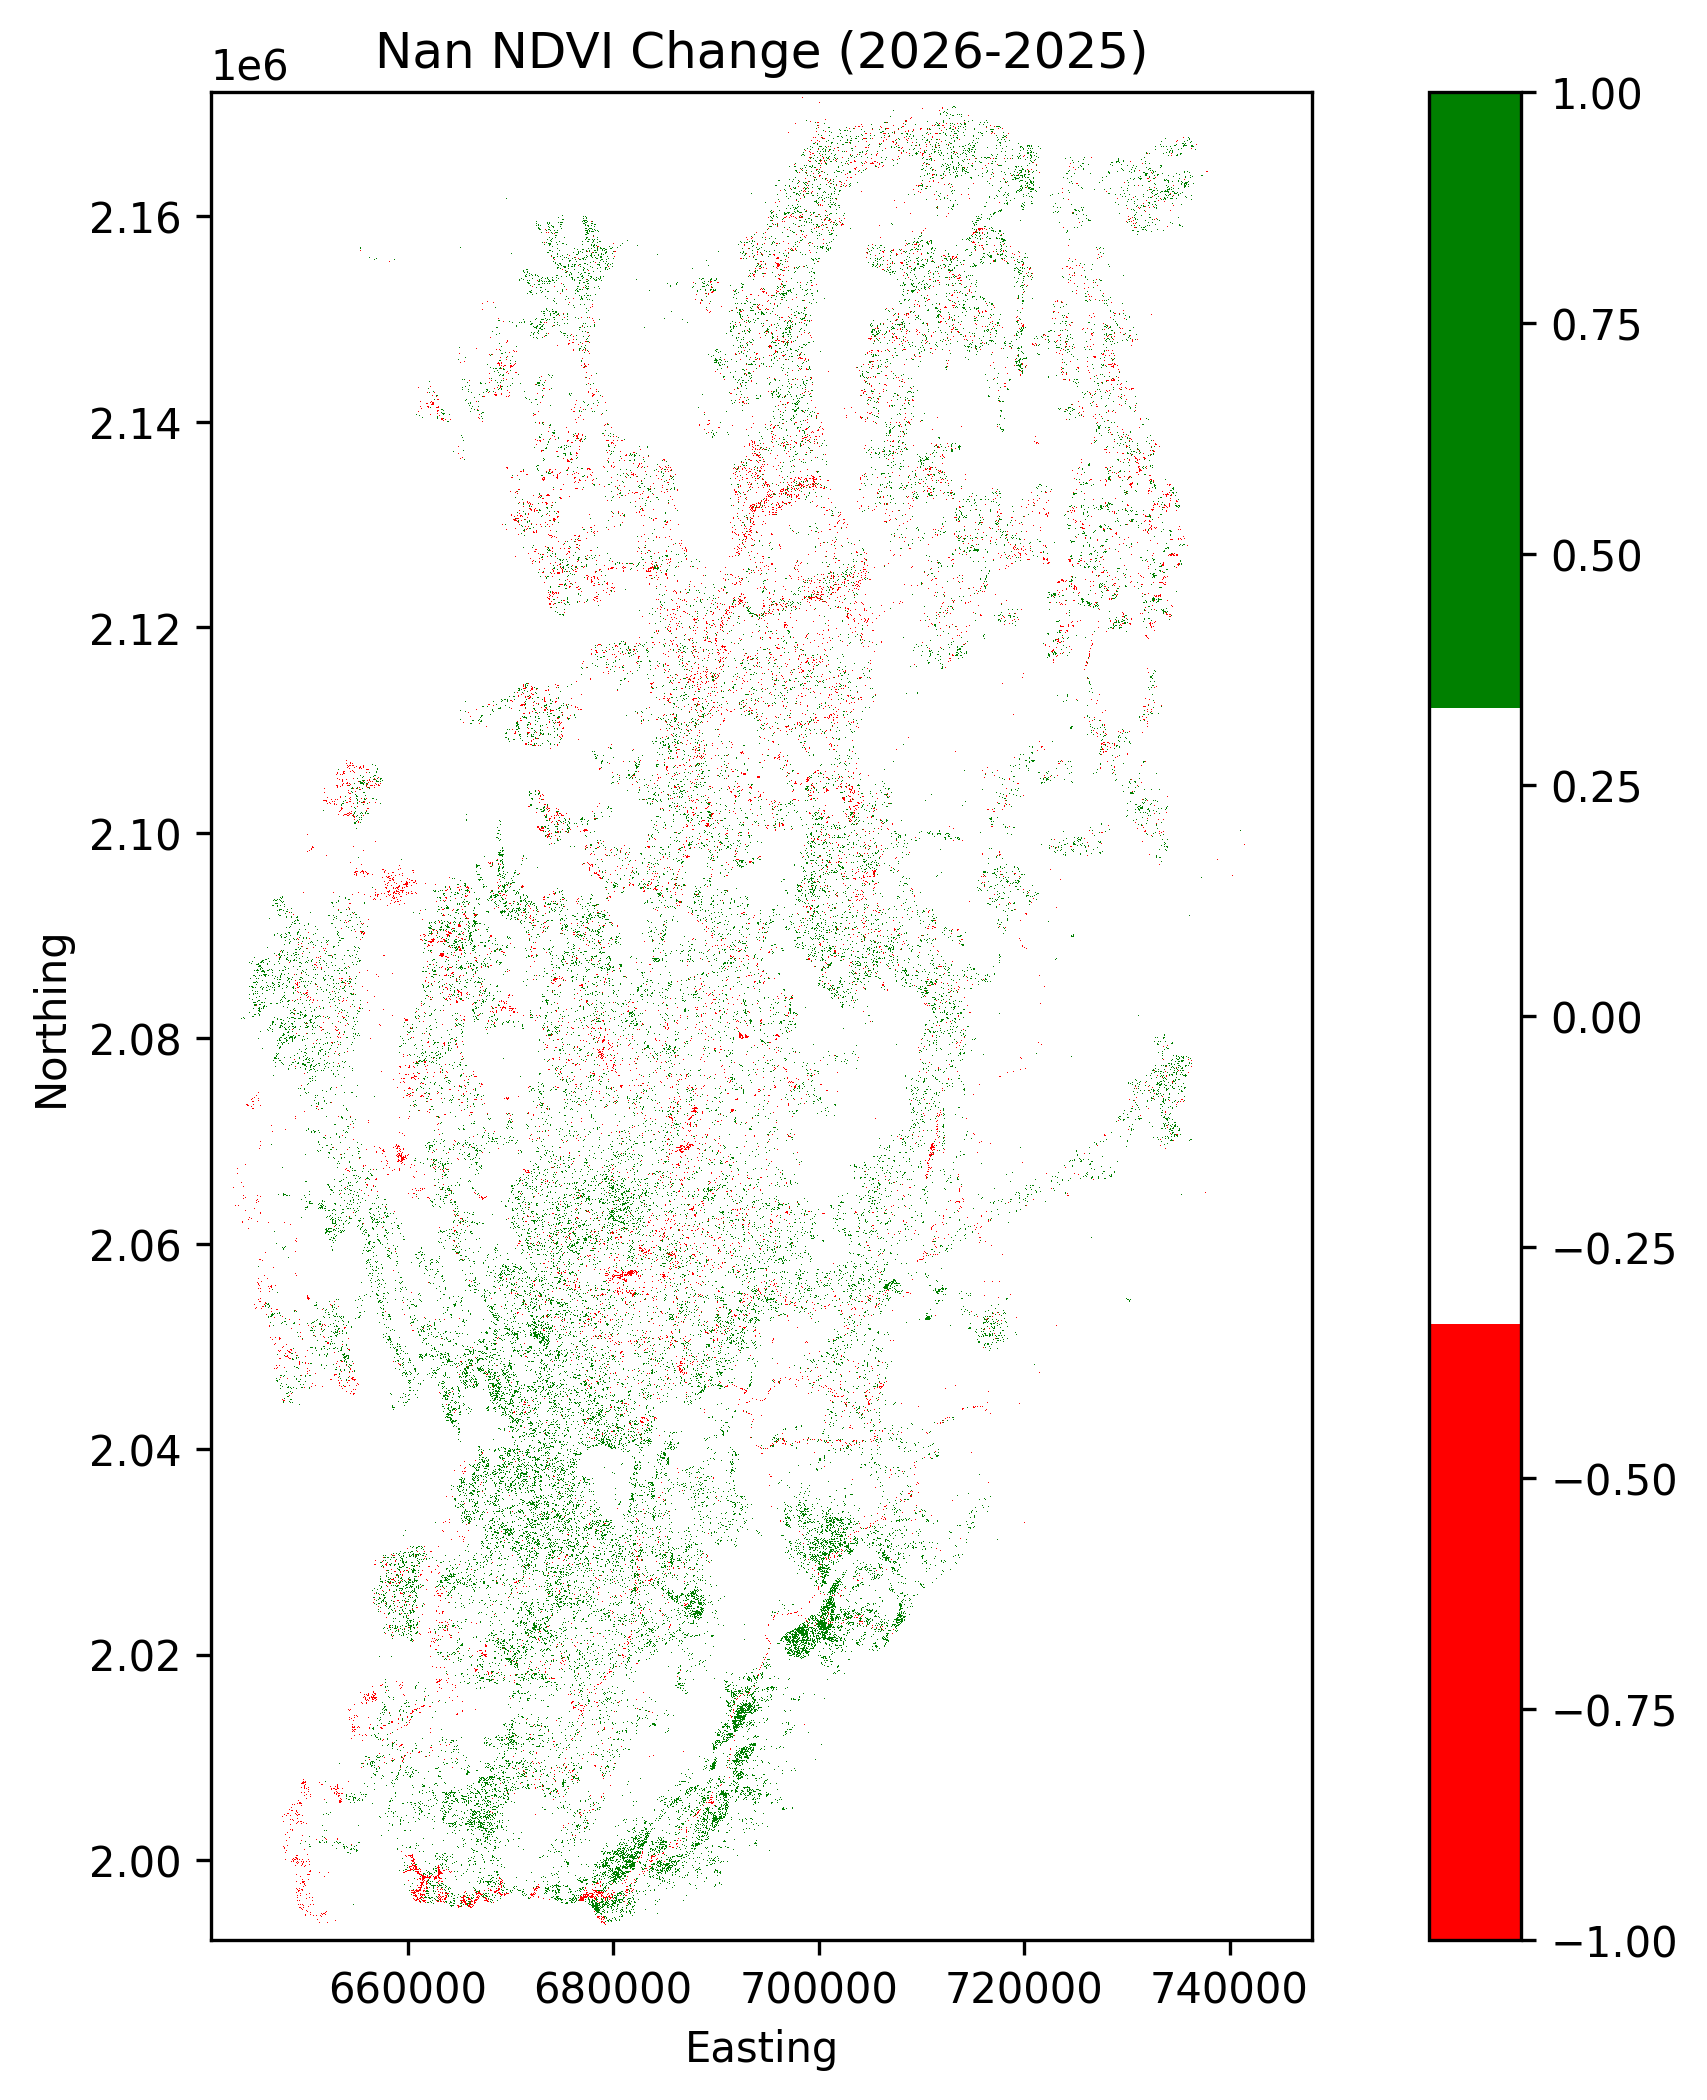

In [ ]:
# สร้าง Interactive map ด้วย Folium

# CRS
Nan_ROI = Nan_ROI.to_crs(epsg=4326)
points = points.to_crs(epsg=4326)

# Threshold
threshold = 0.2

loss_mask = delta_ndvi < -threshold
gain_mask = delta_ndvi > threshold
stable_mask = np.abs(delta_ndvi) <= threshold

# classification map
change_map = np.zeros(delta_ndvi.shape)

change_map[loss_mask] = -1
change_map[stable_mask] = 0
change_map[gain_mask] = 1

# mask ด้วยจังหวัด
mask = geometry_mask(
    Nan_ROI.geometry,
    transform=src1.transform,
    invert=True,
    out_shape=delta_ndvi.shape
)

delta_masked = np.where(mask, delta_ndvi, np.nan)
change_masked = np.where(mask, change_map, np.nan)

# downsample raster
scale = 10

delta_small = delta_masked[::scale, ::scale]
change_small = change_masked[::scale, ::scale]

# colormap continuous
cont_cmap = mcolors.LinearSegmentedColormap.from_list(
    "ndvi",
    ["red","yellow","green"]
)

norm_cont = mcolors.Normalize(vmin=-0.5, vmax=0.5)

rgba_cont = cont_cmap(norm_cont(delta_small))
rgba_cont[np.isnan(delta_small)] = [0,0,0,0]

# colormap change
change_cmap = mcolors.ListedColormap(["red","lightgrey","green"])
norm_change = mcolors.BoundaryNorm([-1.5,-0.5,0.5,1.5], change_cmap.N)

rgba_change = change_cmap(norm_change(change_small))
rgba_change[np.isnan(change_small)] = [0,0,0,0]

rgba_change = (rgba_change * 255).astype("uint8")


# transformer
transformer = Transformer.from_crs(raster_crs, "EPSG:4326", always_xy=True)

# convert coordinates
lon_min, lat_min = transformer.transform(xmin, ymin)
lon_max, lat_max = transformer.transform(xmax, ymax)

raster_bounds = [[lat_min, lon_min], [lat_max, lon_max]]

# map center
bounds = Nan_ROI.total_bounds

center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

m = folium.Map(
    location=[center_lat,center_lon],
    zoom_start=8,
    tiles=None
)

# satellite basemap
folium.TileLayer(
    tiles="Esri.WorldImagery",
    name="Satellite"
).add_to(m)

# province boundary
folium.GeoJson(
    Nan_ROI,
    name="Nan Province",
    style_function=lambda x:{
        "color":"yellow",
        "weight":2,
        "fillOpacity":0
    }
).add_to(m)

# point color function
def point_color(val):

    if val < -threshold:
        return "red"
    elif val > threshold:
        return "green"
    else:
        return "grey"

# monitoring points
for idx,row in points.iterrows():

    popup_text = f"""
    <b>Name:</b> {row['NAME']} <br>
    <b>Subdistrict:</b> {row['TUMBOON']} <br>
    <b>District:</b> {row['AUMPER']} <br>
    <b>Latitude:</b> {row['LATITUDE']} <br>
    <b>Longitude:</b> {row['LONGITUDE']} <br>
    <b>NDVI 2025:</b> {row['NDVI_2025']:.3f} <br>
    <b>NDVI 2026:</b> {row['NDVI_2026']:.3f} <br>
    <b>ΔNDVI:</b> {row['Delta_NDVI']:.3f}
    """

    folium.CircleMarker(
        location=[row["LATITUDE"],row["LONGITUDE"]],
        radius=4,
        color=point_color(row["Delta_NDVI"]),
        fill=True,
        fill_color=point_color(row["Delta_NDVI"]),
        fill_opacity=0.9,
        popup=folium.Popup(popup_text,max_width=300)
    ).add_to(m)

# legend
legend = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 170px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding:10px;
">

<b>ΔNDVI Threshold</b><br>

<span style="color:red;">■</span> Loss (< -0.2)<br>
<span style="color:grey;">■</span> Stable (-0.2 – 0.2)<br>
<span style="color:green;">■</span> Gain (> 0.2)

</div>
"""

m.get_root().html.add_child(folium.Element(legend))

folium.LayerControl().add_to(m)
m.fit_bounds([
    [bounds[1], bounds[0]],
    [bounds[3], bounds[2]]
])
m

[ลิงก์สำหรับเปิด Interactive Map ผ่าน GitHub](https://gustkt.github.io/GE337_Programming_Dev/Nan_Delta_NDVI_in_forest_hotspots_Map.html)

เมื่อทำการเปรียบเทียบ ΔNDVI (2026-2025) กับจุด Hotspots บริเวณพื้นที่ป่าไม้ของจังหวัดน่านในช่วงปี 2025 พบว่าส่วนใหญ่ค่า NDVI ไม่เปลี่ยนแปลง (-0.2 < threshold < 0.2) มีจุดที่มีค่า NDVI เพิ่มขึ้น (threshold > 0.2) กระจุกตัวทางบริเวณตอนล่าง และทางตะวันออกเฉียงใต้ของจังหวัด แสดงให้เห็นถึงการฟื้นตัวของธรรมชาติ อย่างไรก็ตาม พบจุดที่มีค่า NDVI ลดลง (threshold < -0.2) จำนวน 7 จุด ซึ่งส่วนใหญ่เป็นพื้นที่สีเขียวที่สำคัญของจังหวัด

In [12]:

points[points["Delta_NDVI"] < -0.2][["LATITUDE","LONGITUDE","NAME","TUMBOON","AUMPER","NDVI_2025","NDVI_2026","Delta_NDVI"]]

,LATITUDE,LONGITUDE,NAME,TUMBOON,AUMPER,NDVI_2025,NDVI_2026,Delta_NDVI
22,19.47490,100.85558,ป่าน้ำยาว และป่าน้ำสวด,งอบ,ทุ่งช้าง,0.819527,0.481390,-0.338137
55,19.21925,101.14426,อุทยานแห่งชาติดอยภูคา,ดงพญา,บ่อเกลือ,0.879276,0.521480,-0.357796
70,18.60232,100.78966,พื้นที่อื่น,ไหล่น่าน,เวียงสา,0.453807,0.171141,-0.282666
96,19.19422,100.81603,ป่าน้ำยาว และป่าน้ำสวด,เจดีย์ชัย,ปัว,0.842752,0.388353,-0.454399
129,19.52927,101.19612,ป่าดอยภูคาและป่าผาแดง,ขุนน่าน,เฉลิมพระเกียรติ,0.764511,0.522563,-0.241948
148,19.01593,100.48251,เขตรักษาพันธุ์สัตว์ป่าดอยผาช้าง,สะเนียน,เมืองน่าน,0.885314,0.680482,-0.204832
312,18.45335,100.88746,อุทยานแห่งชาติศรีน่าน,น้ำมวบ,เวียงสา,0.746316,0.507270,-0.239046


**การวิเคราะห์ความสัมพันธ์ของ NDVI กับภูมิประเทศ**

* ใช้ DEM เพื่อดูว่าความสูงของพื้นที่มีผลต่อ NDVI หรือไม่

In [ ]:
# เปิดไฟล์ DEM
dem_src = rasterio.open("/content/drive/MyDrive/Data for program dev/lab_3/Nan_DEM/Nan_DEM.tif")
dem_data = dem_src.read(1)

In [ ]:
# Case 1 : ใช้ DEM เพื่อดูว่าความสูงของพื้นที่มีผลต่อ NDVI ปีล่าสุดหรือไม่ (NDVI2026 = ndvi2)

# resample ให้ grid เท่ากับ ndvi2
dem_resampled = np.empty_like(ndvi2)

reproject(
    source=dem_data,
    destination=dem_resampled,
    src_transform=dem_src.transform,
    src_crs=dem_src.crs,
    dst_transform=src1.transform,
    dst_crs=src1.crs,
    resampling=Resampling.bilinear
)

In [ ]:
# flatten เพื่อวิเคราะห์
dem_flat = dem_resampled.flatten()
ndvi_flat = ndvi2.flatten()

mask = (~np.isnan(dem_flat)) & (~np.isnan(ndvi_flat))

dem_clean = dem_flat[mask]
ndvi_clean = ndvi_flat[mask]

print(dem_resampled.shape)
print(ndvi2.shape)

In [ ]:
plt.scatter(dem_clean, ndvi_clean, s=1)
plt.xlabel("Elevation (m)")
plt.ylabel("NDVI 2026")
plt.title("NDVI 2026 vs Elevation from DEM")
plt.show()

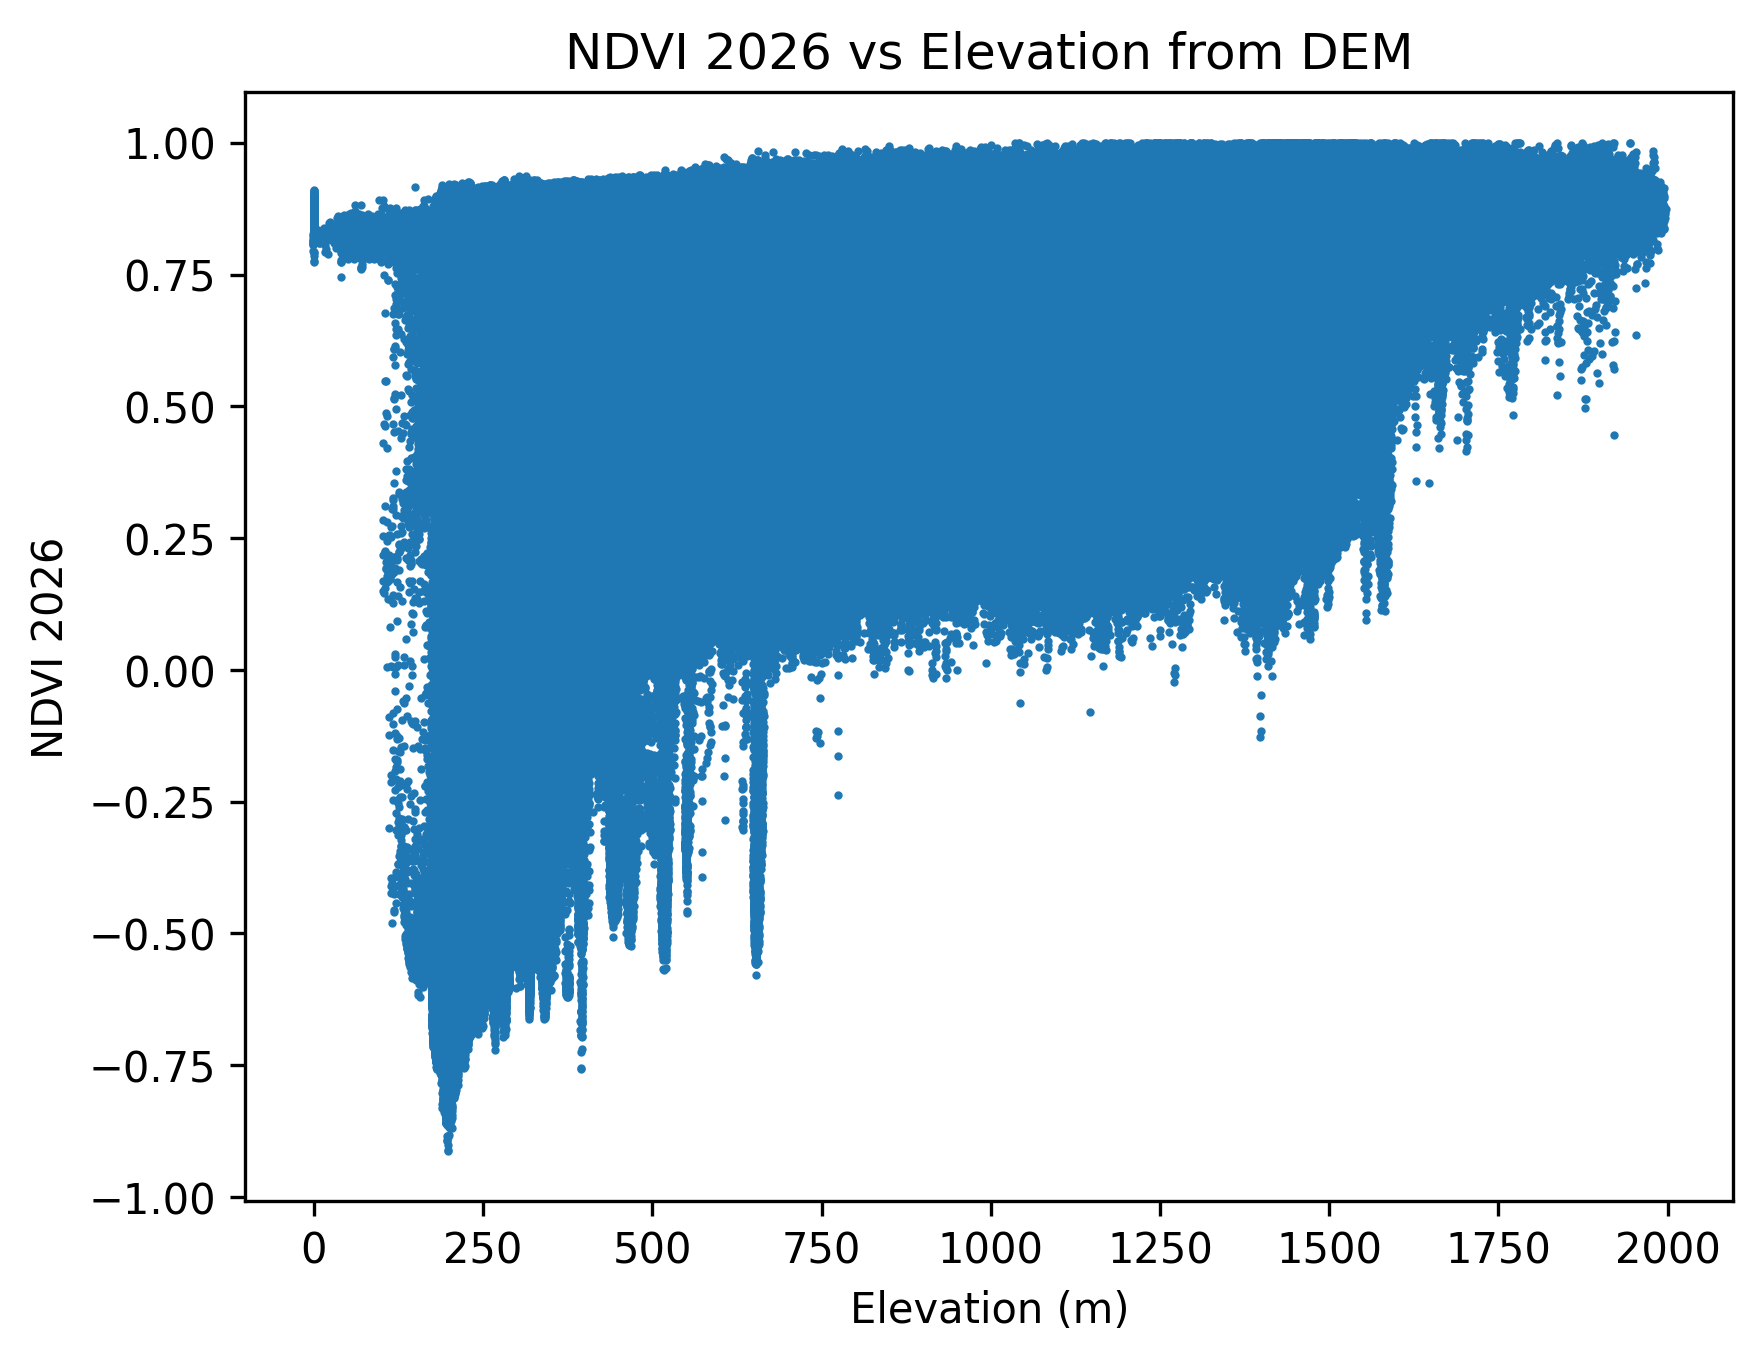

จากกราฟเมื่อทำการเปรียบเทียบ NDVI ปี 2026 กับ DEM พบว่า NDVI ส่วนใหญ่กระจุกอยู่ประมาณ 0.6-0.9 แต่ก็พบค่า NDVI สูง ๆ ในทุกระดับความสูง โดยจุดที่มีค่า NDVI ต่ำหรือติดลบพบมากในพื้นที่ต่ำช่วงความสูงประมาณ 100-300 เมตรซึ่งสามารถตีความได้ว่าพื้นที่ต่ำมี land cover หลากหลายกว่า เช่น เมือง เกษตร หรือน้ำทำให้ NDVI ต่ำหรือกระจายมาก ในขณะที่พื้นที่สูงมักเป็นพื้นที่ป่าจึงทำให้มีค่า NDVI ค่อนข้างสูงและสม่ำเสมอ ดังนั้นแนวโน้มคือ **ยิ่งพื้นที่สูง ค่า NDVI จะค่อนข้างสูงและเสถียร แต่ก็ไม่ได้แสดงความสัมพันธ์กันแบบชัดเจน**

In [ ]:
# Case 2 : ใช้ DEM เพื่อดูว่าความสูงของพื้นที่มีผลต่อการเปลี่ยนแปลงของ NDVI หรือไม่ (ΔNDVI = delta_ndvi)

# เปิดไฟล์ DEM
dem_src = rasterio.open("/content/drive/MyDrive/Data for program dev/lab_3/Nan_DEM/Nan_DEM.tif")
dem_data = dem_src.read(1)

# resample ให้ grid เท่ากับ delta_ndvi
dem_resampled = np.empty_like(delta_ndvi)

reproject(
    source=dem_data,
    destination=dem_resampled,
    src_transform=dem_src.transform,
    src_crs=dem_src.crs,
    dst_transform=src1.transform,
    dst_crs=src1.crs,
    resampling=Resampling.bilinear
)

In [ ]:
# flatten เพื่อวิเคราะห์
dem_flat = dem_resampled.flatten()
ndvi_flat = delta_ndvi.flatten()

mask = (~np.isnan(dem_flat)) & (~np.isnan(ndvi_flat))

dem_clean = dem_flat[mask]
ndvi_clean = ndvi_flat[mask]

print(dem_resampled.shape)
print(delta_ndvi.shape)

In [ ]:
plt.scatter(dem_clean, ndvi_clean, s=1)
plt.xlabel("Elevation (m)")
plt.ylabel("ΔNDVI (2026-2025)")
plt.title("ΔNDVI (2026-2025) vs Elevation from DEM")
plt.show()

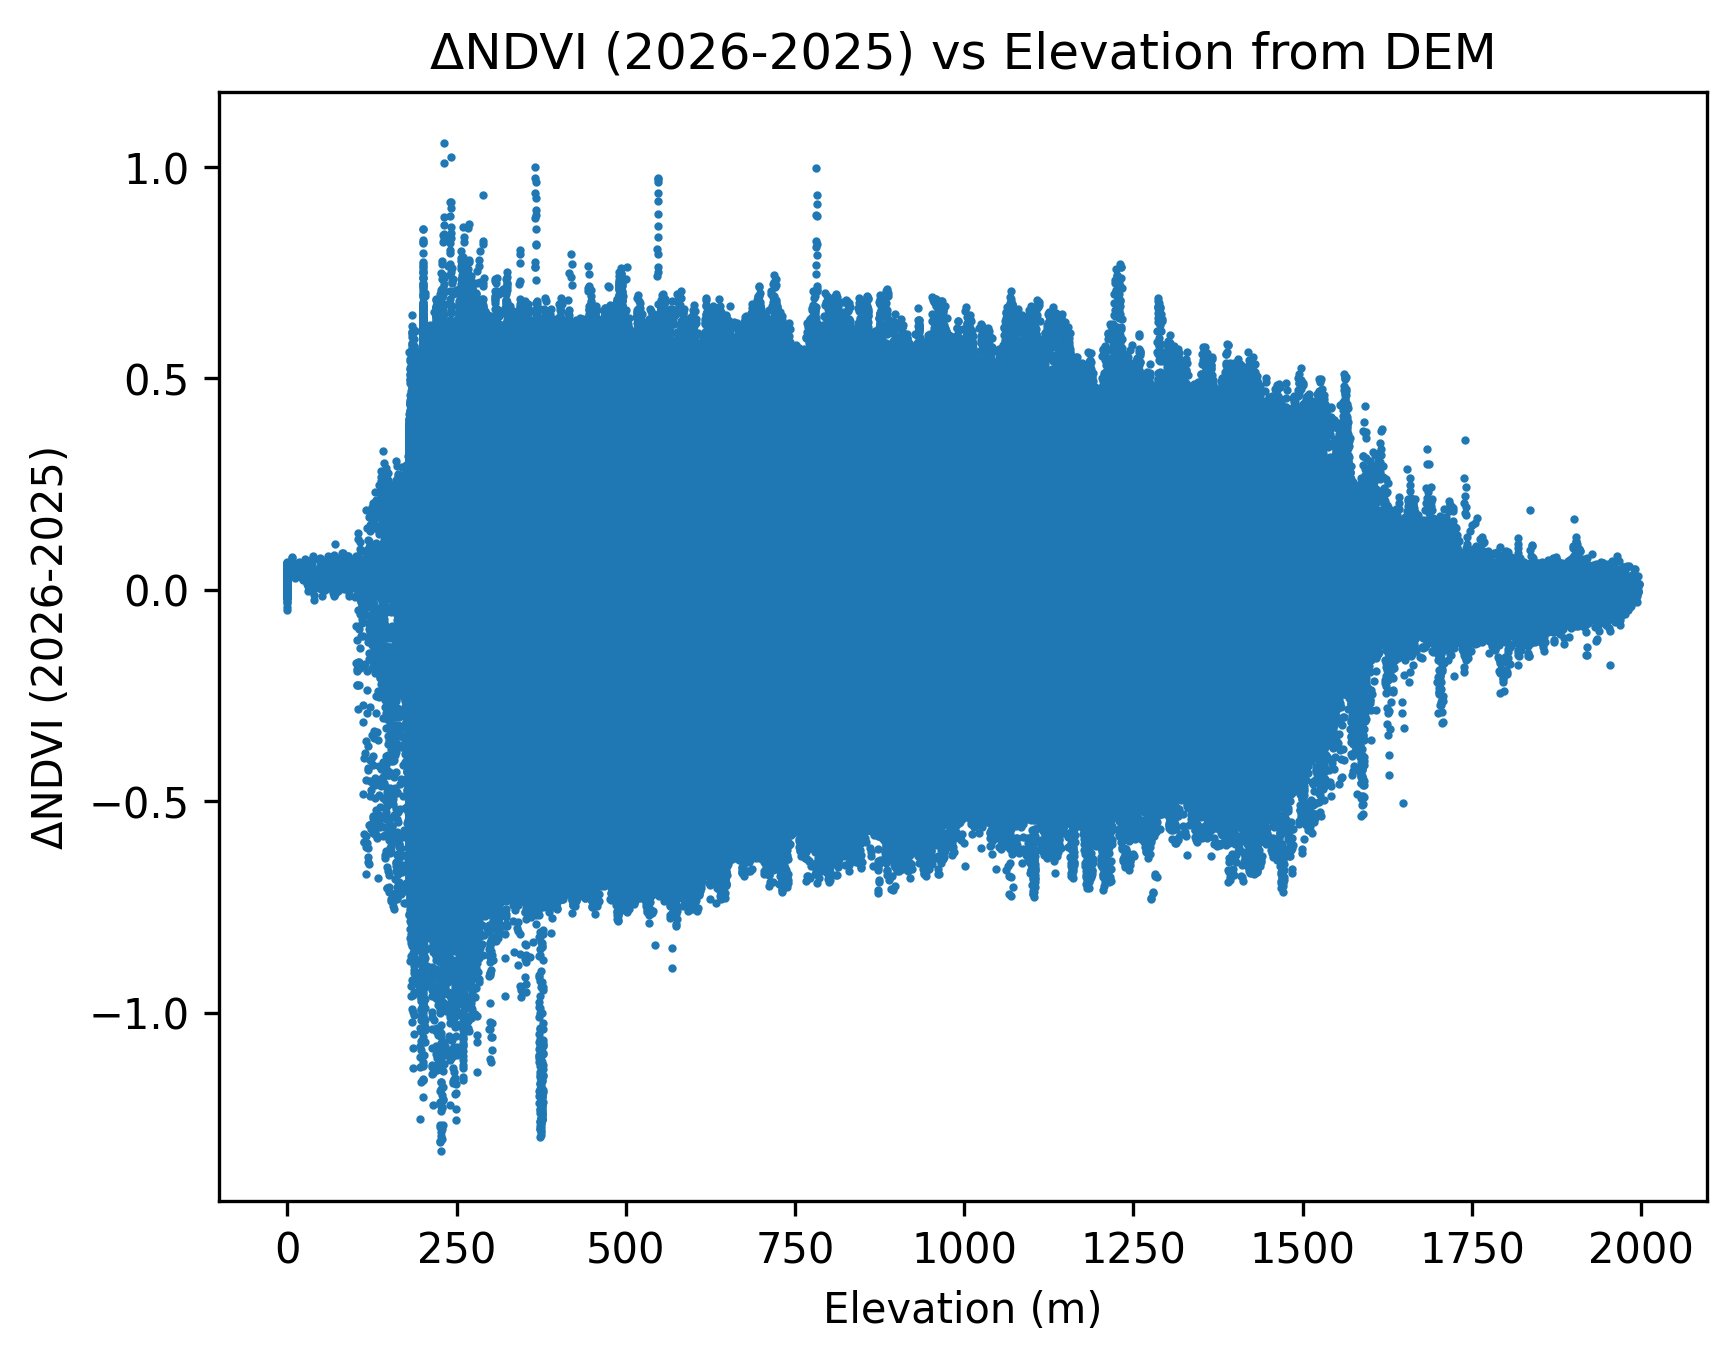

จากกราฟเมื่อทำการเปรียบเทียบ ΔNDVI (2026-2025) กับ DEM พบว่าค่า ΔNDVI กระจายประมาณ -0.5 ถึง 0.5 เกือบทุกระดับความสูง โดยไม่มีรูปแบบที่ชัดเจนว่าที่สูงหรือที่ต่ำมีการเปลี่ยนแปลงมากกว่า ดังนั้นสามารถตีความได้ว่า**ระดับความสูงไม่ได้ควบคุมการเปลี่ยนแปลง NDVI ระหว่างปี 2025 กับ 2026**

* คำนวณค่าเฉลี่ยของ NDVI ที่ระดับความสูงต่าง ๆ และวิเคราะห์แนวโน้ม

In [ ]:
# Case 1 : คำนวณค่าเฉลี่ยของ NDVI ปีล่าสุดที่ระดับความสูงต่าง ๆ (NDVI2026 = ndvi2)

# เปิดไฟล์ DEM
dem_src = rasterio.open("/content/drive/MyDrive/Data for program dev/lab_3/Nan_DEM/Nan_DEM.tif")
dem_data = dem_src.read(1)

# สร้าง dataframe
df = pd.DataFrame({
    "elevation": dem_clean,
    "ndvi2026": ndvi_clean
})

# แบ่งช่วงความสูง
bins = np.arange(0, np.max(df["elevation"]) + 20, 20)

df["elev_bin"] = pd.cut(df["elevation"], bins)

# ดึงค่า mean
ndvi_mean_by_elev = df.groupby("elev_bin")["ndvi2026"].mean()

In [ ]:
plt.figure(figsize=(8,6))

ndvi_mean_by_elev.plot(marker="o")

plt.title("Mean NDVI 2026 by Elevation")
plt.xlabel("Elevation (m)")
plt.ylabel("Mean NDVI 2026")

plt.xticks(rotation=45)
plt.show()

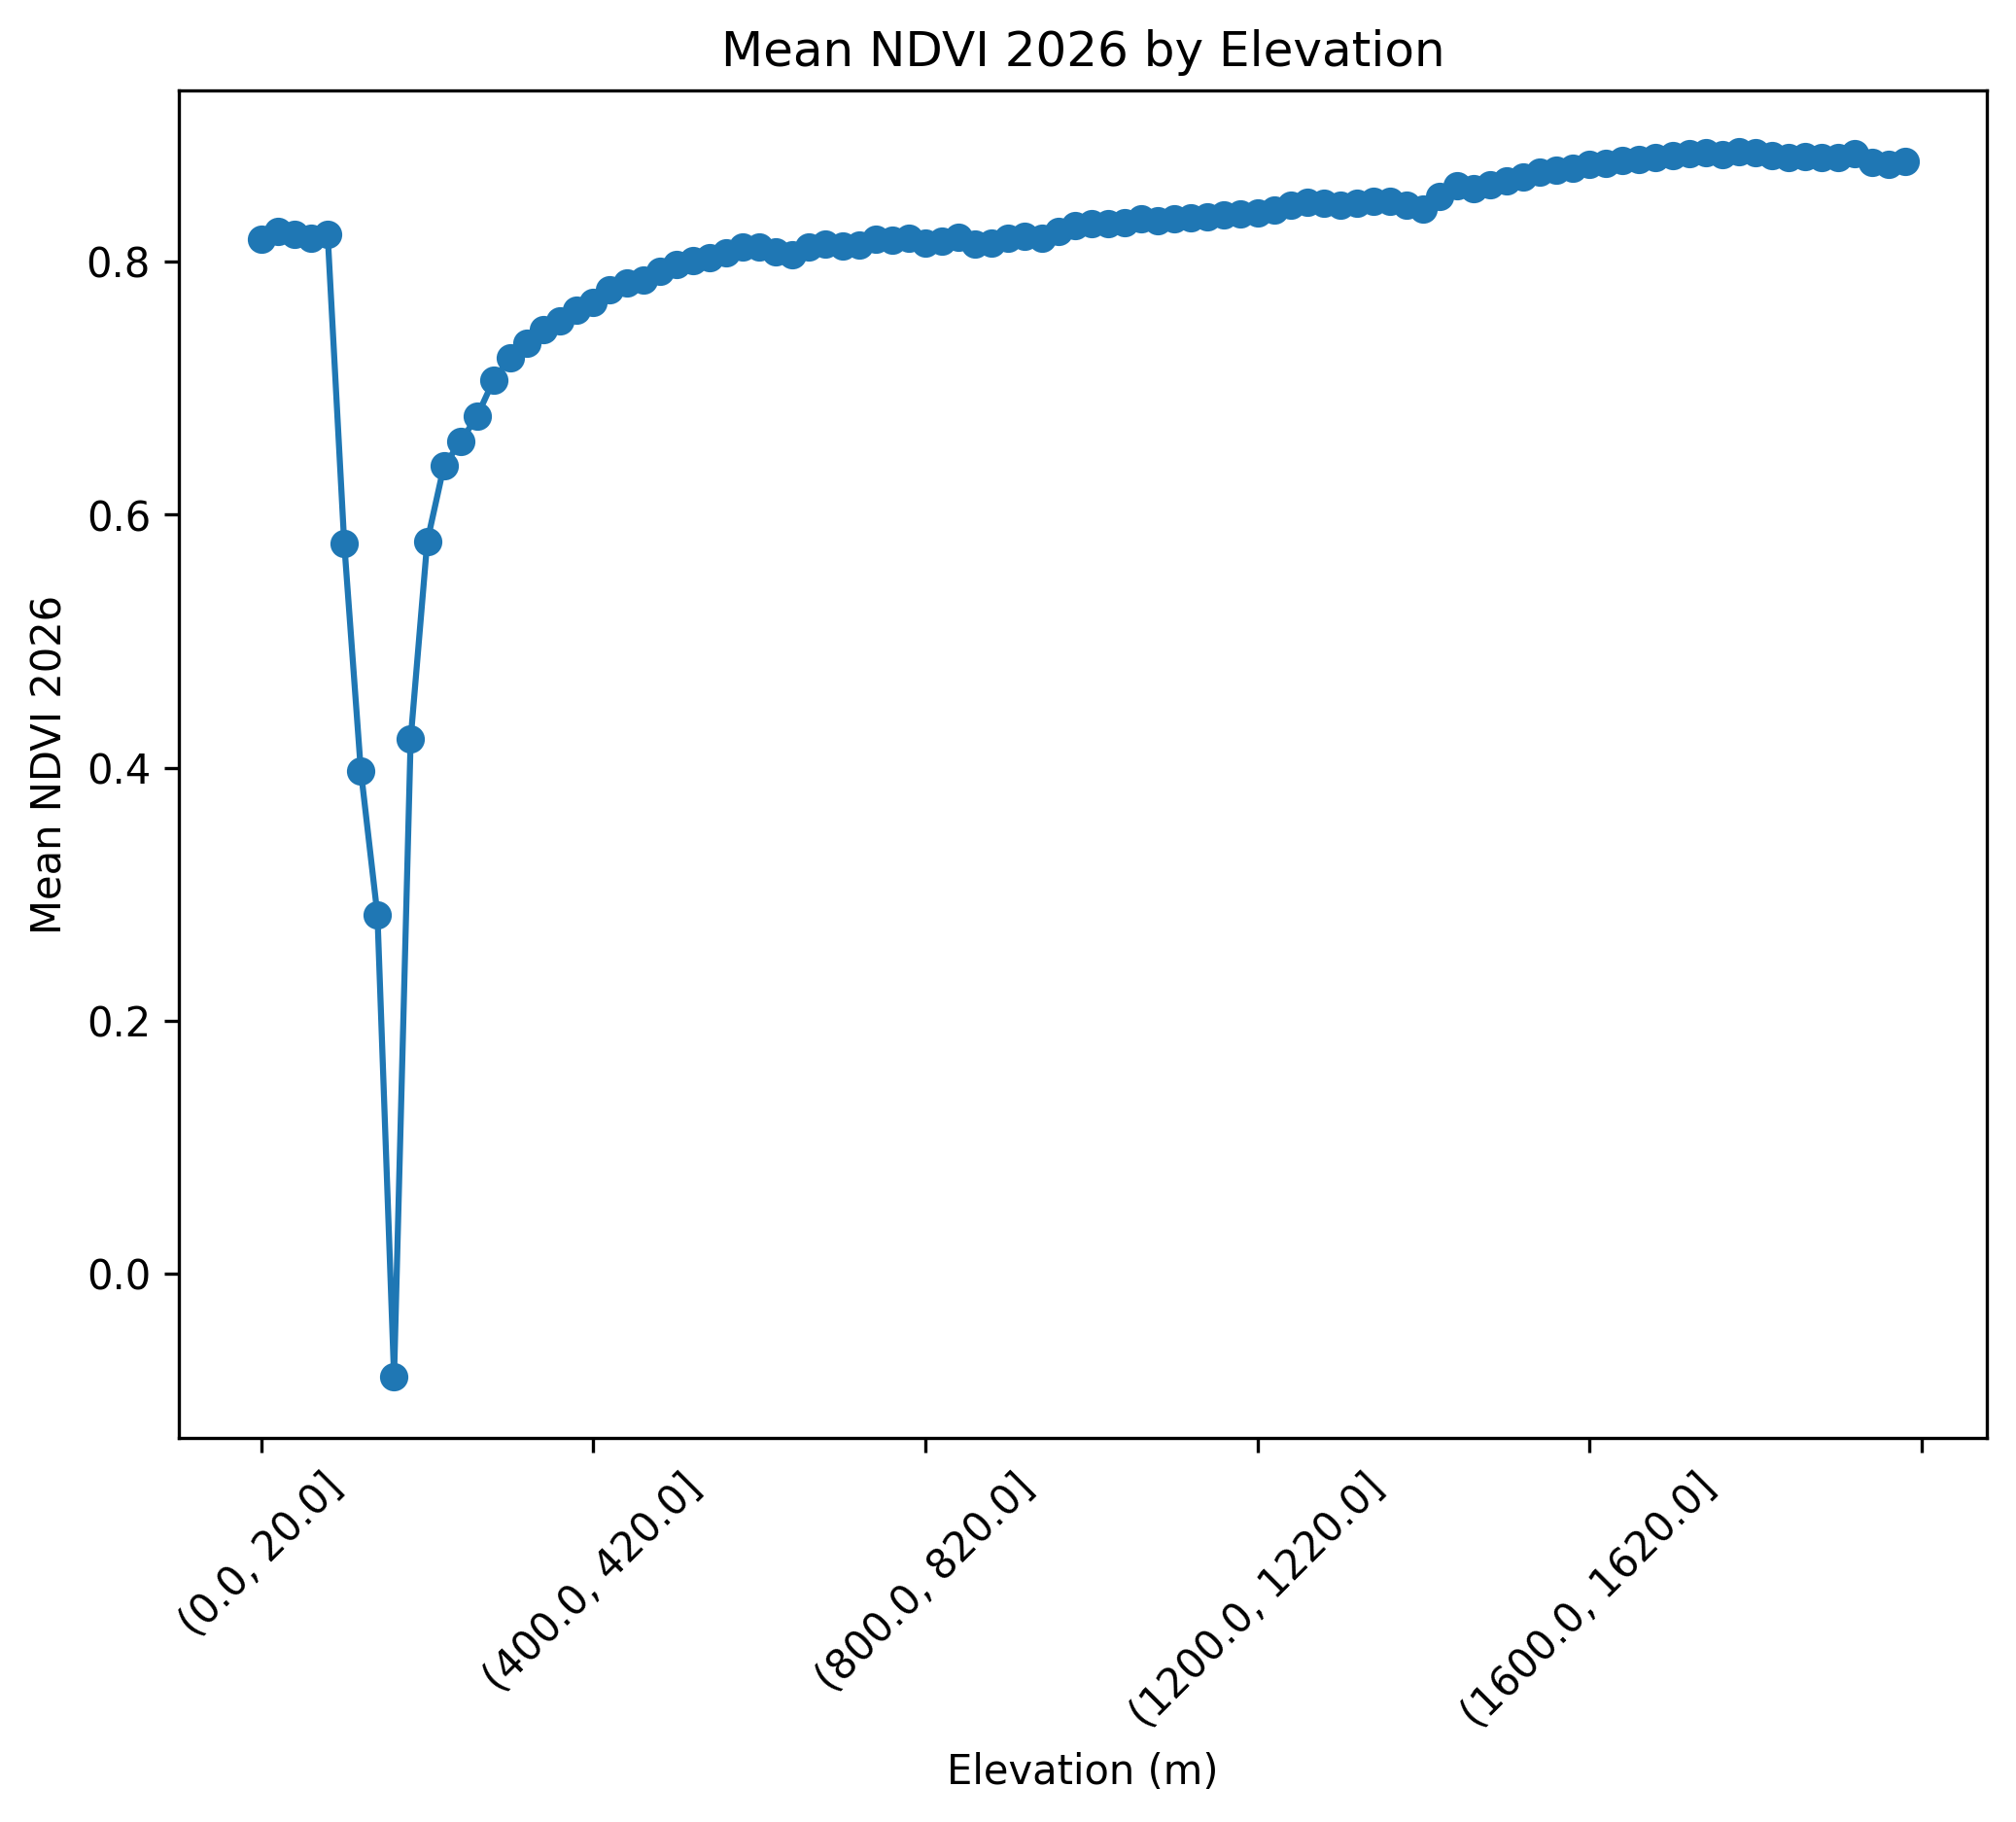

จากกราฟที่แสดงค่าเฉลี่ยของ NDVI ปี 2026 ที่ระดับความสูงต่าง ๆ พบว่า พื้นที่ต่ำมากมีค่า NDVI เฉลี่ยค่อนข้างสูงอยู่ที่ประมาณ 0.8 จากนั้นช่วง 100-200 เมตร NDVI ลดลงอย่างชัดเจน แต่กลับสูงขึ้นอย่างต่อเนื่องในช่วงตั้งแต่ 200 เมตรขึ้นไป และจะค่อนข้างขึ้นสูง และคงที่ในช่วง 1000 เมตรขึ้นไป ซึ่งเกิดจากการกระจายของ land cover ที่พื้นที่ต่ำมากมักพบพื้นที่เกษตรหรือป่าทำให้มีค่า NDVI สูง ในขณะที่ระดับความสูงต่ำ-กลางมักเป็นเมือง หรือพื้นที่โล่ง ทำให้มีค่า NDVI ต่ำ และในที่สูงมักพบป่าธรรมชาติทำให้มีค่า NDVI พุ่งสูงขึ้น ดังนั้นสามารถสรุปแนวโน้มได้ว่า **NDVI มีแนวโน้มเพิ่มขึ้นตามระดับความสูงหลังจากที่ระดับความสูงประมาณ 200 เมตร**

In [ ]:
# Case 2 : คำนวณค่าเฉลี่ยของ ΔNDVI ปีล่าสุดที่ระดับความสูงต่าง ๆ (ΔNDVI = delta_ndvi)

# เปิดไฟล์ DEM
dem_src = rasterio.open("/content/drive/MyDrive/Data for program dev/lab_3/Nan_DEM/Nan_DEM.tif")
dem_data = dem_src.read(1)


# สร้าง dataframe
df = pd.DataFrame({
    "elevation": dem_clean,
    "delta NDVI": ndvi_clean
})

# แบ่งช่วงความสูง
bins = np.arange(0, np.max(df["elevation"]) + 20, 20)

df["elev_bin"] = pd.cut(df["elevation"], bins)

# ดึงค่า mean
delta_ndvi_mean_by_elev = df.groupby("elev_bin")["delta NDVI"].mean()

In [ ]:
plt.figure(figsize=(8,6))

delta_ndvi_mean_by_elev.plot(marker="o")

plt.title("Mean ΔNDVI (2026-2025) by Elevation")
plt.xlabel("Elevation (m)")
plt.ylabel("Mean ΔNDVI (2026-2025)")

plt.xticks(rotation=45)
plt.show()

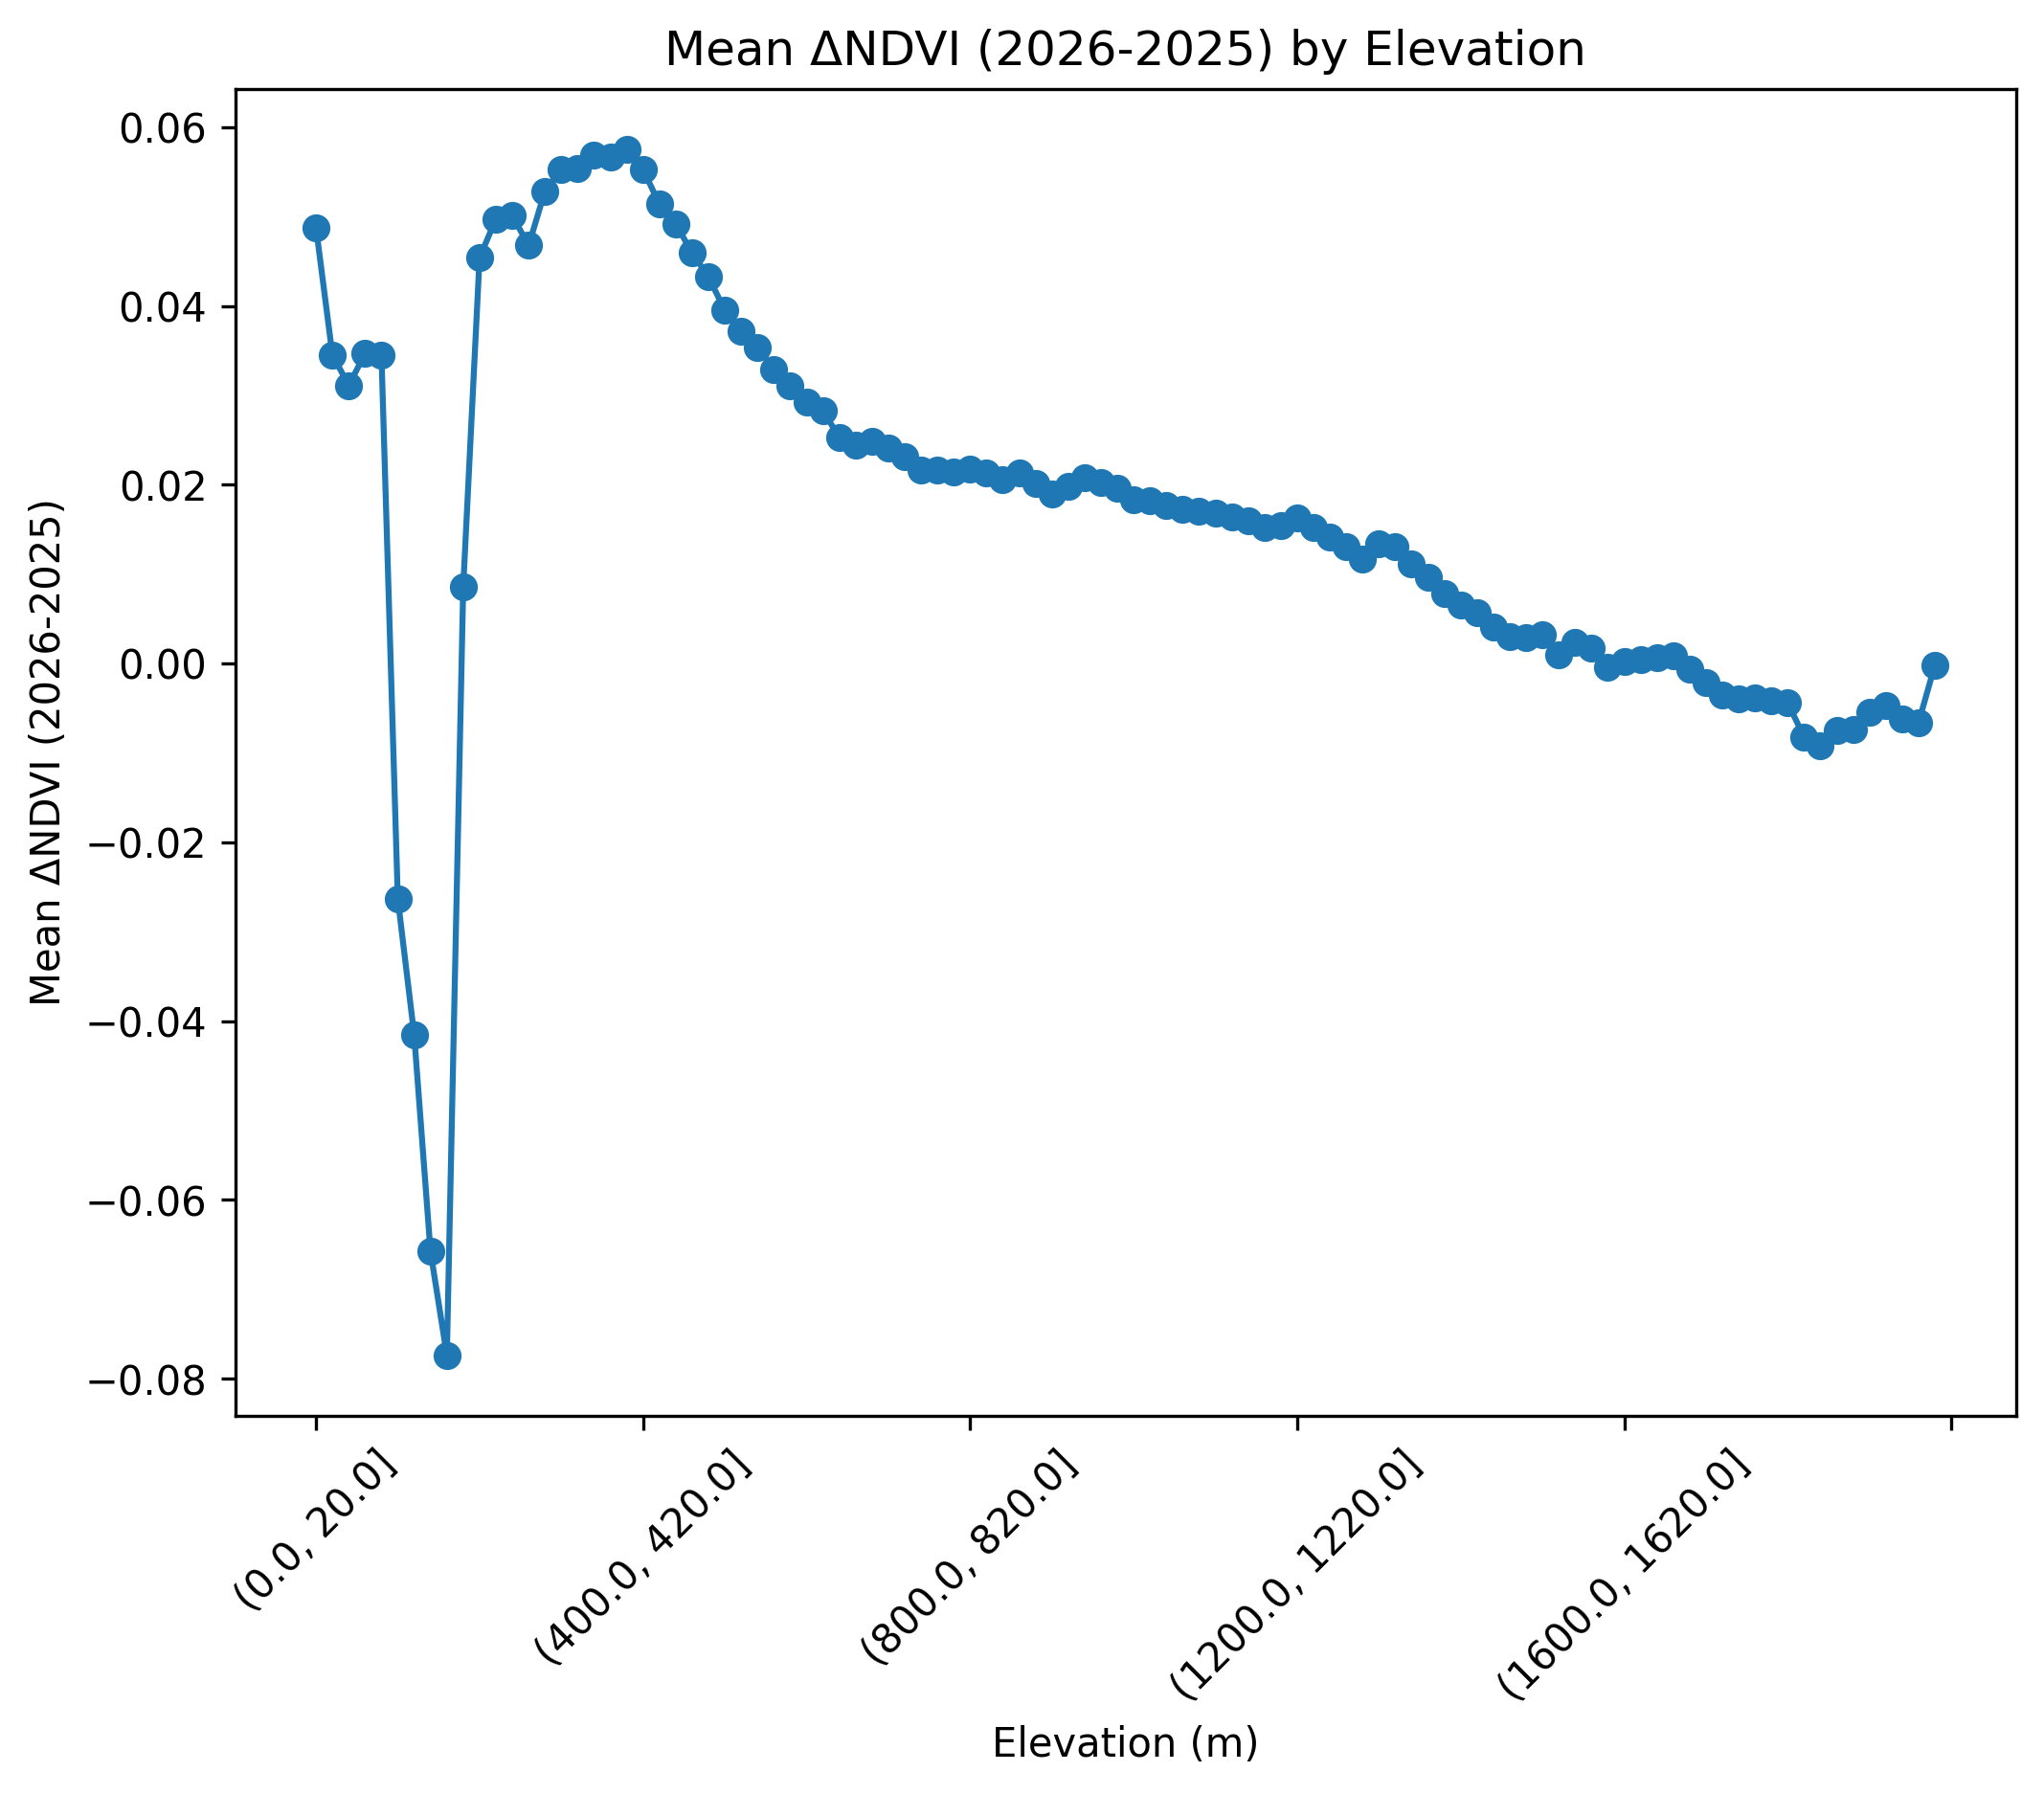

จากกราฟที่แสดงค่าเฉลี่ยของ ΔNDVI ระหว่างปี 2025 กับ 2026 ที่ระดับความสูงต่าง ๆ พบว่า NDVI มีแนวโน้มเพิ่มขึ้นตามระดับความสูงโดยเฉพาะตั้งแต่ระดับประมาณ 200 เมตรขึ้นไป พื้นที่สูง (> 1000 เมตร) จะมีค่า NDVI ที่สูงและค่อนข้างคงที่ และการเปลี่ยนแปลงของ NDVI พบมากในพื้นที่ต่ำ-ปานกลาง แสดงให้เห็นว่า**พื้นที่สูงจะมีความเสถียรของพืชพรรณ และ NDVI มากกว่า**

**การสรุปผล**

* แสดงกราฟ Histogram ของการเปลี่ยนแปลง NDVI

In [ ]:
# Case 1 : Histogram without threshold
# เอาค่า NDVI ที่ไม่ใช่ NaN
ndvi_clean = delta_ndvi[~np.isnan(delta_ndvi)]

plt.figure(figsize=(8,6), dpi=300)

plt.hist(ndvi_clean, bins=50)

plt.title("Histogram of NDVI Change (2026–2025)")
plt.xlabel("ΔNDVI")
plt.ylabel("Number of Pixels")
plt.show()

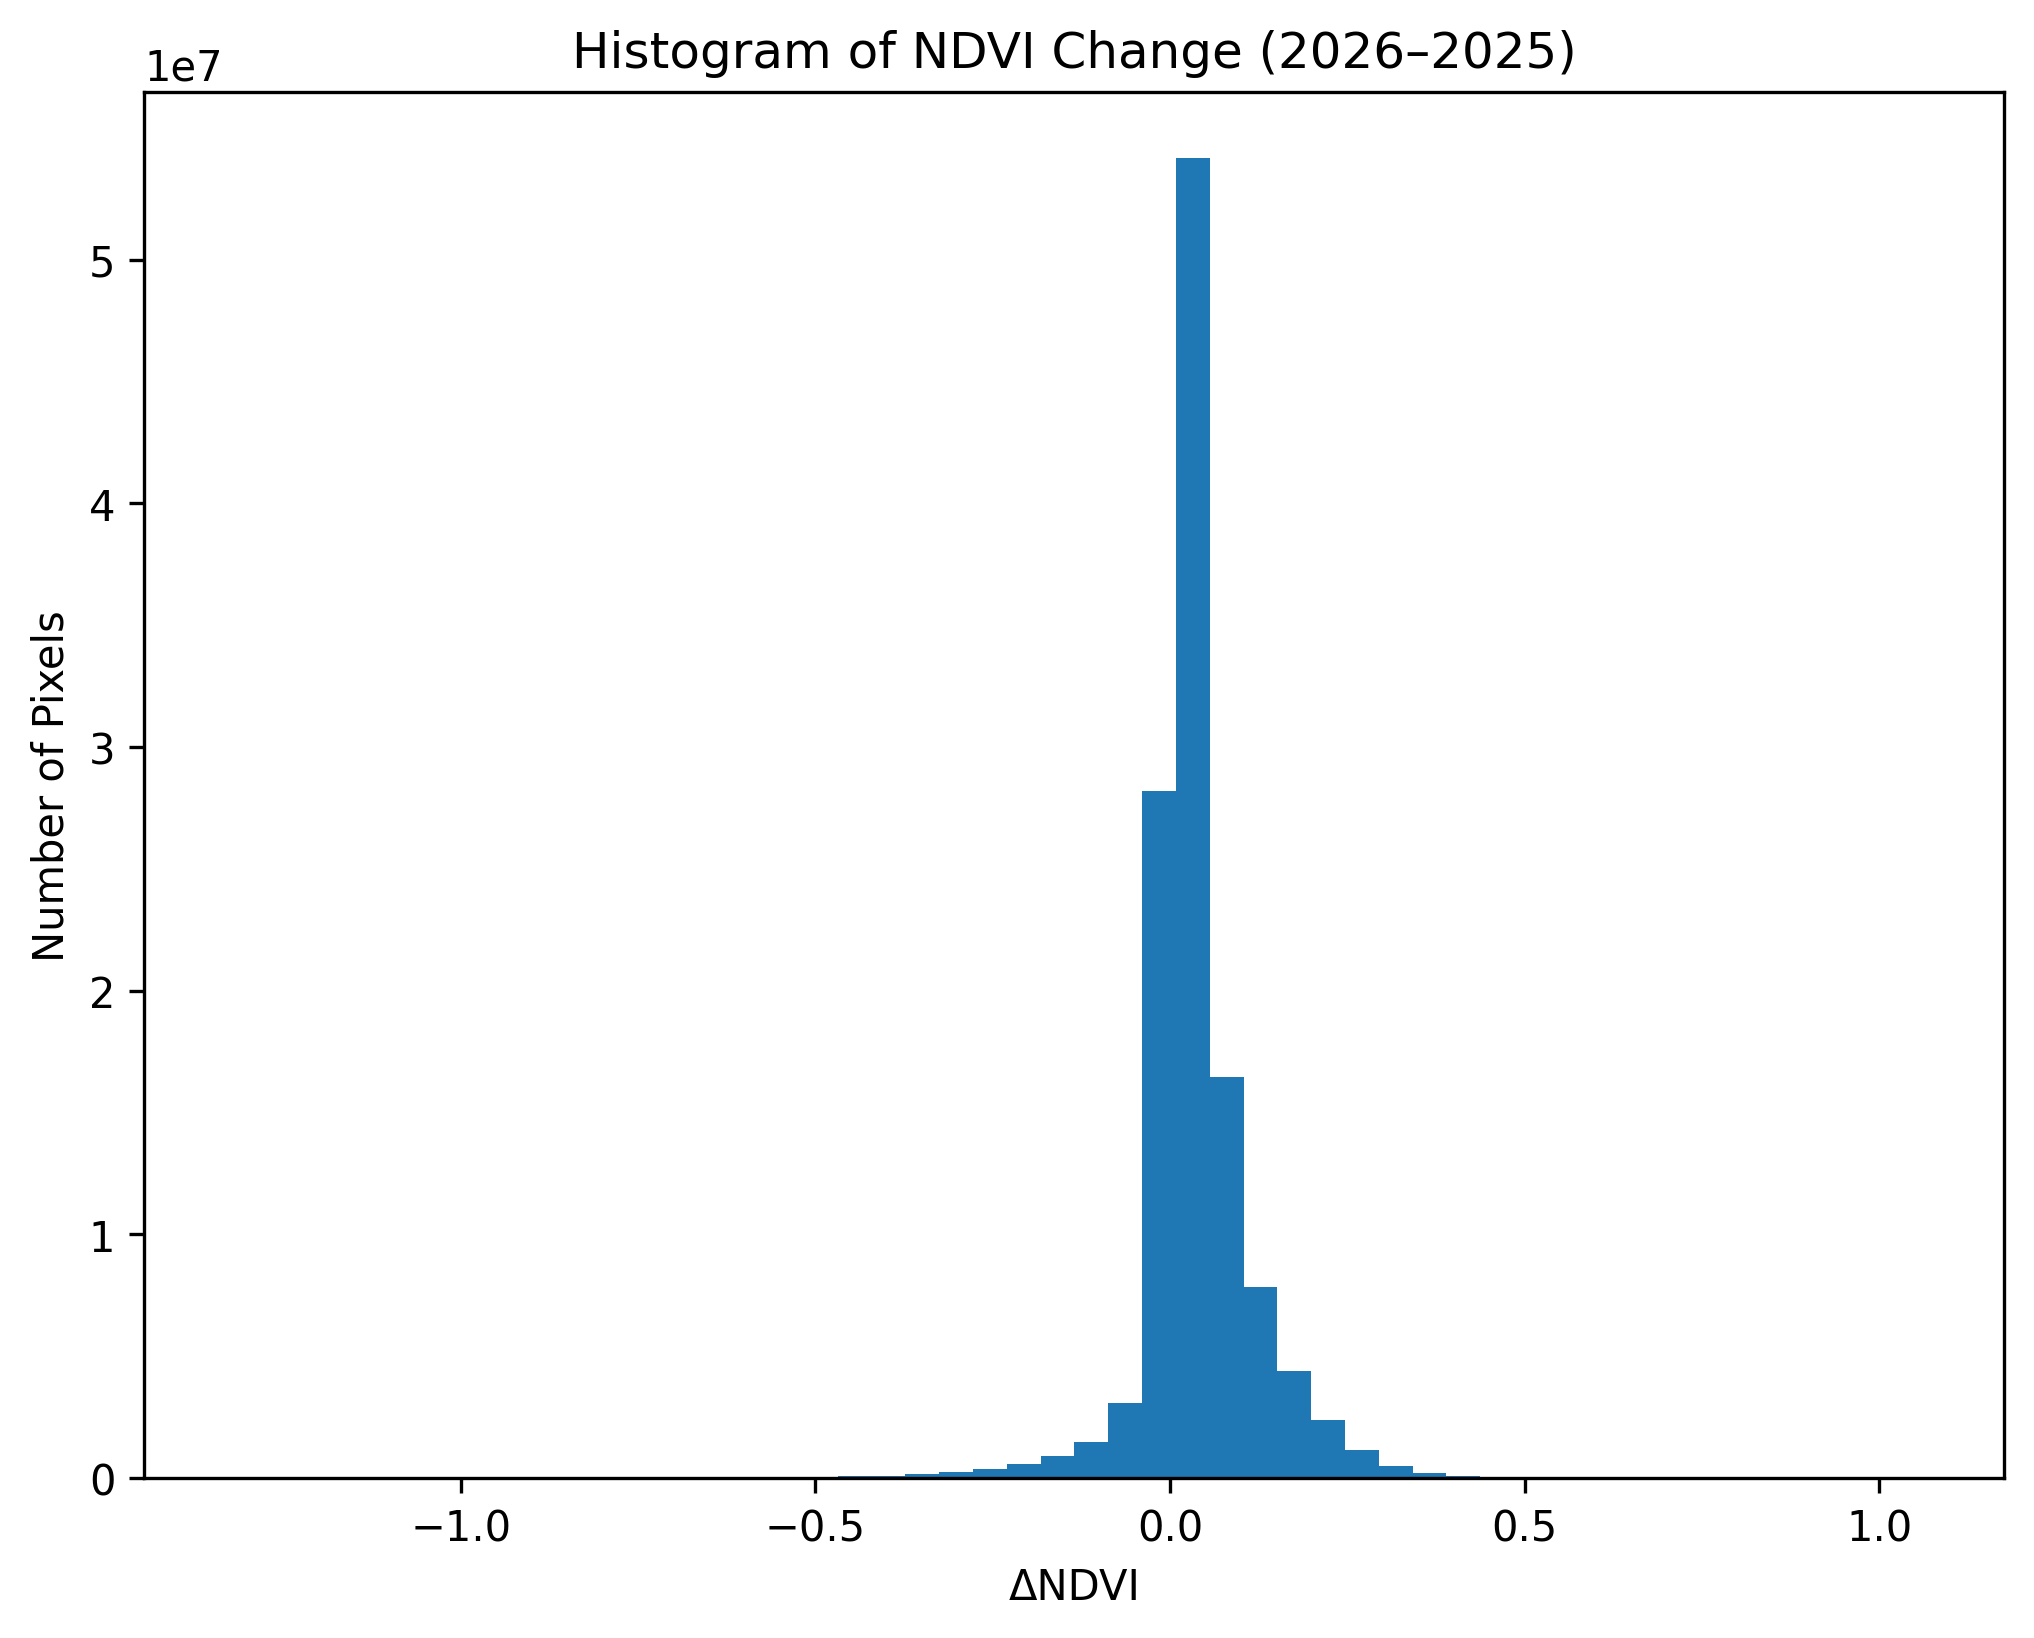

In [ ]:
# Case 2 : Histogram with threshold
# เอาค่า NDVI ที่ไม่ใช่ NaN
ndvi_clean = delta_ndvi[~np.isnan(delta_ndvi)]

# กำหนด threshold
decrease = ndvi_clean[ndvi_clean <= -0.2]
stable   = ndvi_clean[(ndvi_clean > -0.2) & (ndvi_clean < 0.2)]
increase = ndvi_clean[ndvi_clean >= 0.2]

plt.figure(figsize=(8,6), dpi=300)

plt.hist(decrease, bins=50, color="red", alpha=0.7, label="Decrease (≤ -0.2)")
plt.hist(stable, bins=50, color="gray", alpha=0.6, label="No change (-0.2 to 0.2)")
plt.hist(increase, bins=50, color="green", alpha=0.7, label="Increase (≥ 0.2)")

plt.axvline(-0.2, linestyle="--")
plt.axvline(0.2, linestyle="--")

plt.title("Histogram of NDVI Change (2026–2025) with threshold")
plt.xlabel("ΔNDVI")
plt.ylabel("Number of Pixels")

plt.legend()
plt.savefig(r'D:\GE337_Programming_Dev\lab_3\Histogram of NDVI Change (2026–2025) with threshold.png', dpi=300, bbox_inches="tight")
plt.show()

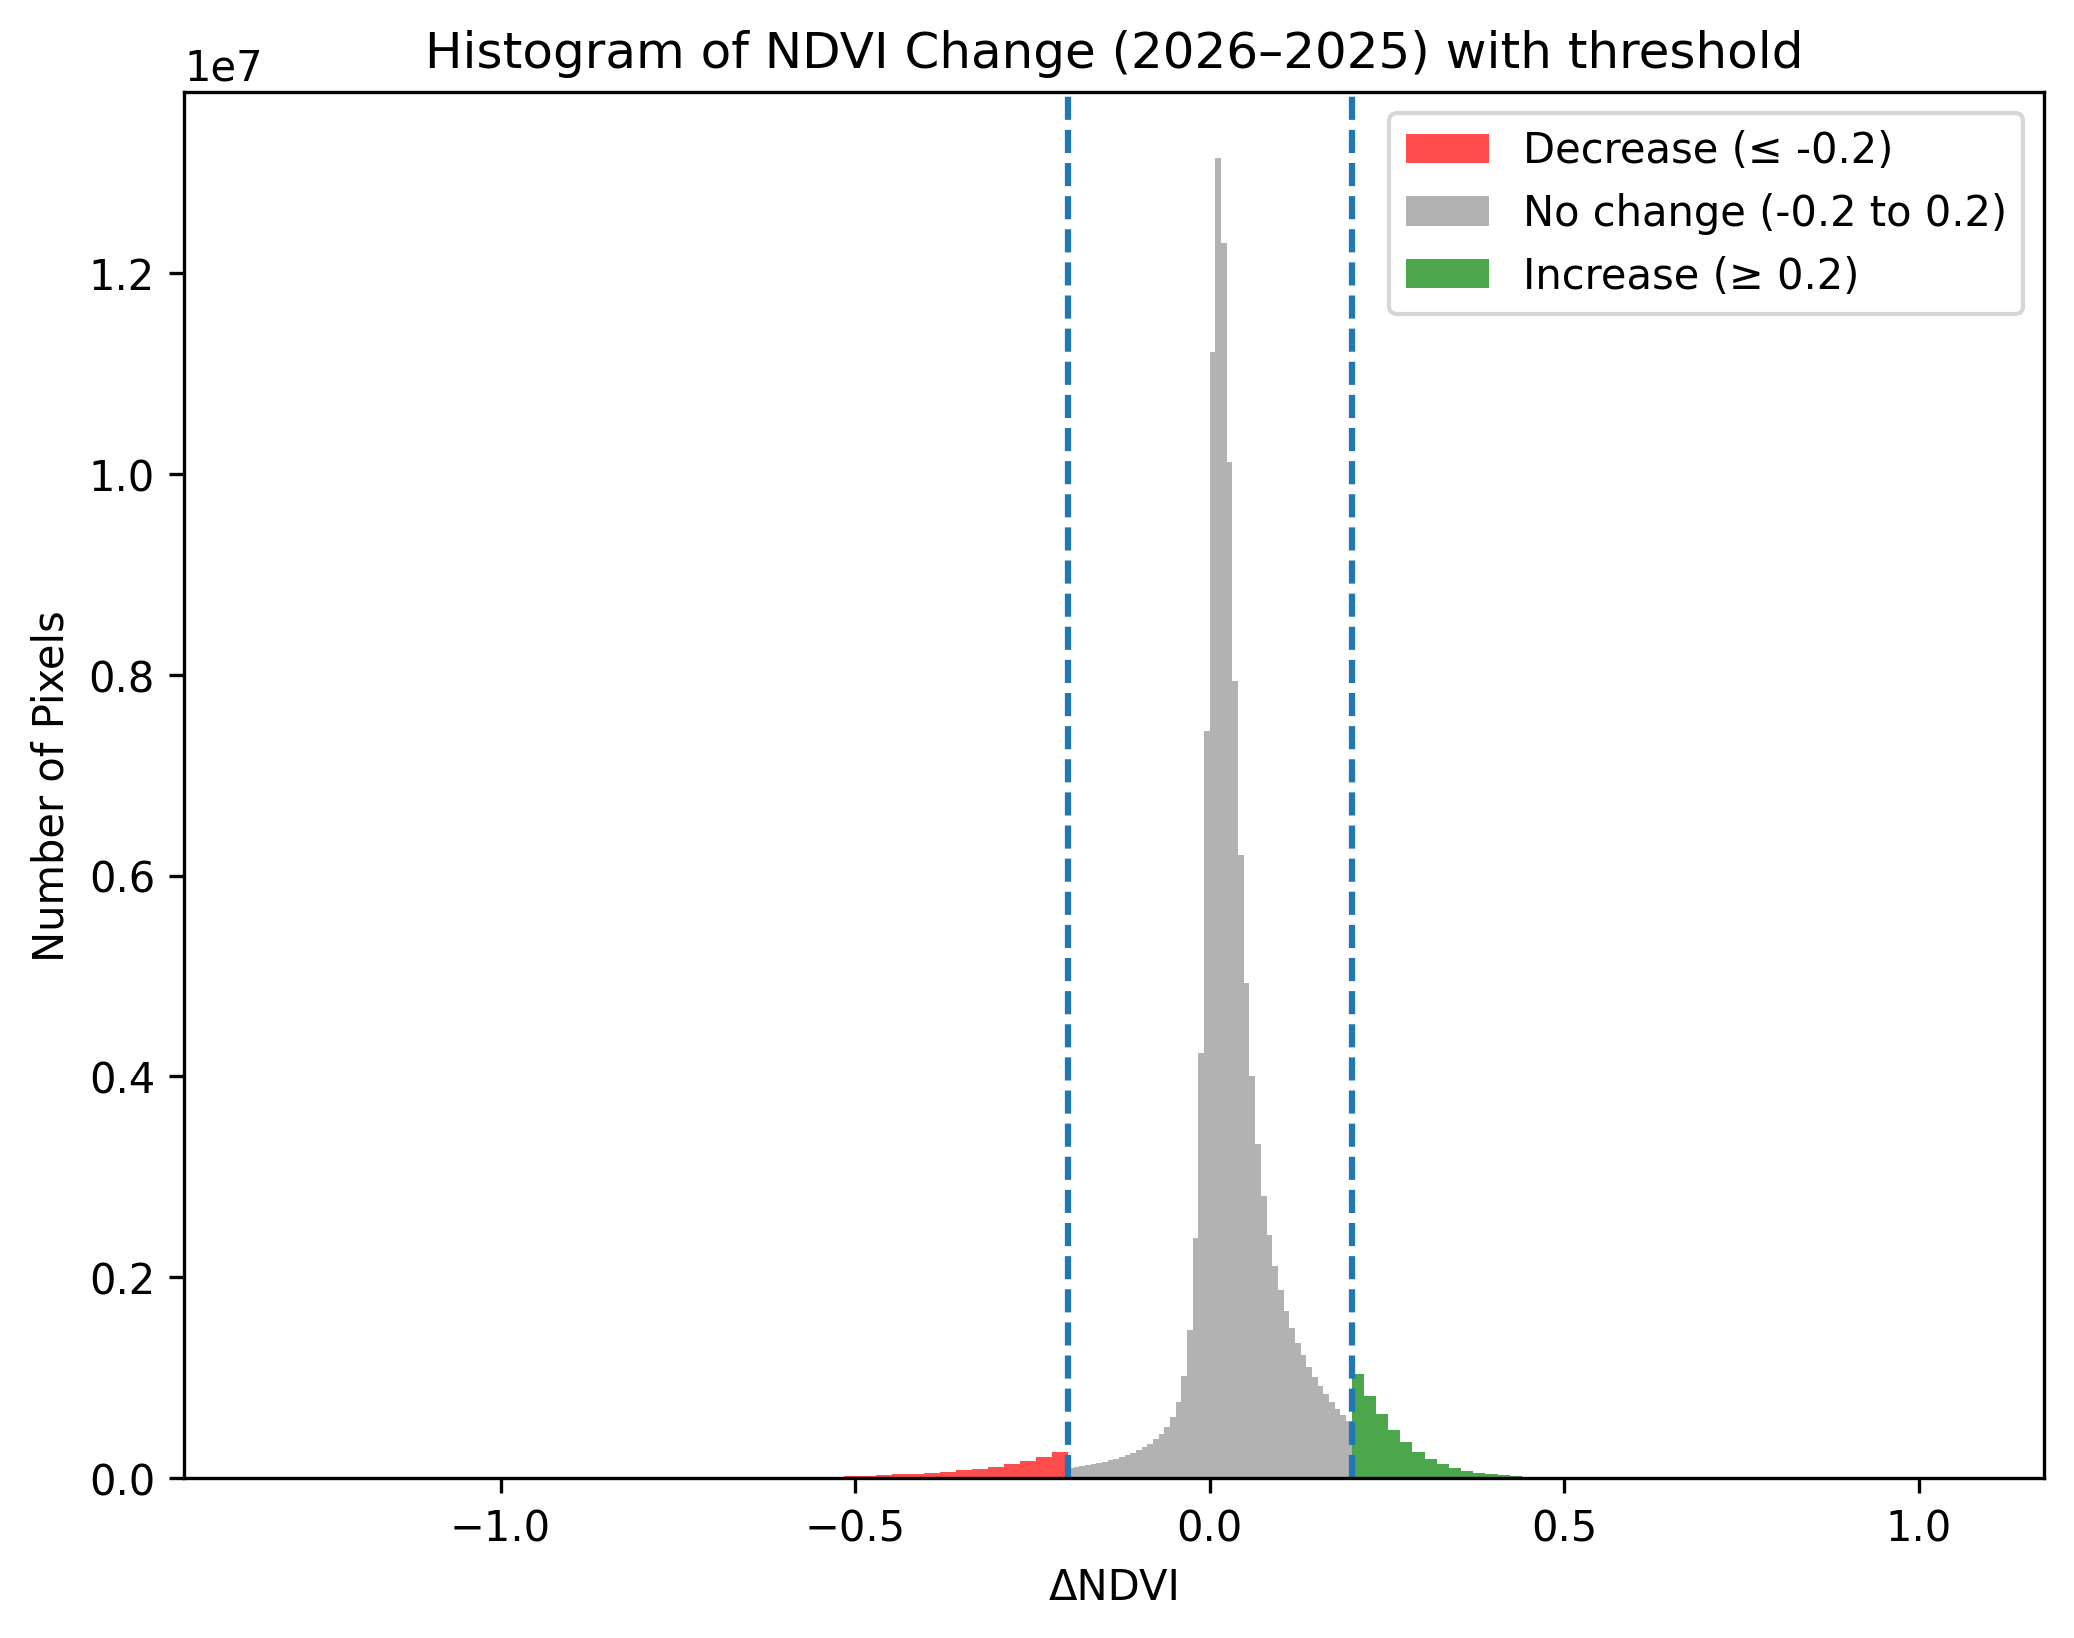

In [ ]:
# คิดพื้นที่ที่ NDVI ลดลง/คงเดิม/เพิ่มขึ้น เป็น %
total = len(ndvi_clean)

print("Decrease:", len(decrease)/total*100)
print("Stable:", len(stable)/total*100)
print("Increase:", len(increase)/total*100)

Decrease: 1.1421559257701048

Stable: 95.33191279764942

Increase: 3.525931276580478

จาก Histogram พบว่าพื้นที่ส่วนใหญ่ของจังหวัดน่านมีค่า NDVI คงที่ (-0.2 < threshold < 0.2) คิดเป็นประมาณ 95.3% ของจังหวัด มี NDVI เพิ่มขึ้น (threshold > 0.2) ประมาณ 3.5% และมี NDVI ลดลง (threshold < -0.2) ประมาณ 1.1%

* อธิบายว่าพื้นที่ใดมี NDVI เพิ่มขึ้นหรือลดลง

พบพื้นที่ที่มี NDVI เพิ่มขึ้น (threshold > 0.2) กระจายทั่วจังหวัดน่านโดยเฉพาะพื้นที่ภูเขาและป่าธรรมชาติทางตอนกลางและตอนใต้ของจังหวัด รวมไปถึงบริเวณพื้นที่ลาดเขาที่มีพืชพรรณหนาแน่น ในขณะที่พื้นที่ที่มี NDVI ลดลง (threshold < -0.2) มีการกระจายทั่วจังหวัดเช่นเดียวกันโดยเฉพาะบนพื้นที่ลาดเขา และพื้นที่บางส่วนใกล้ที่ราบลุ่มแม่น้ำ

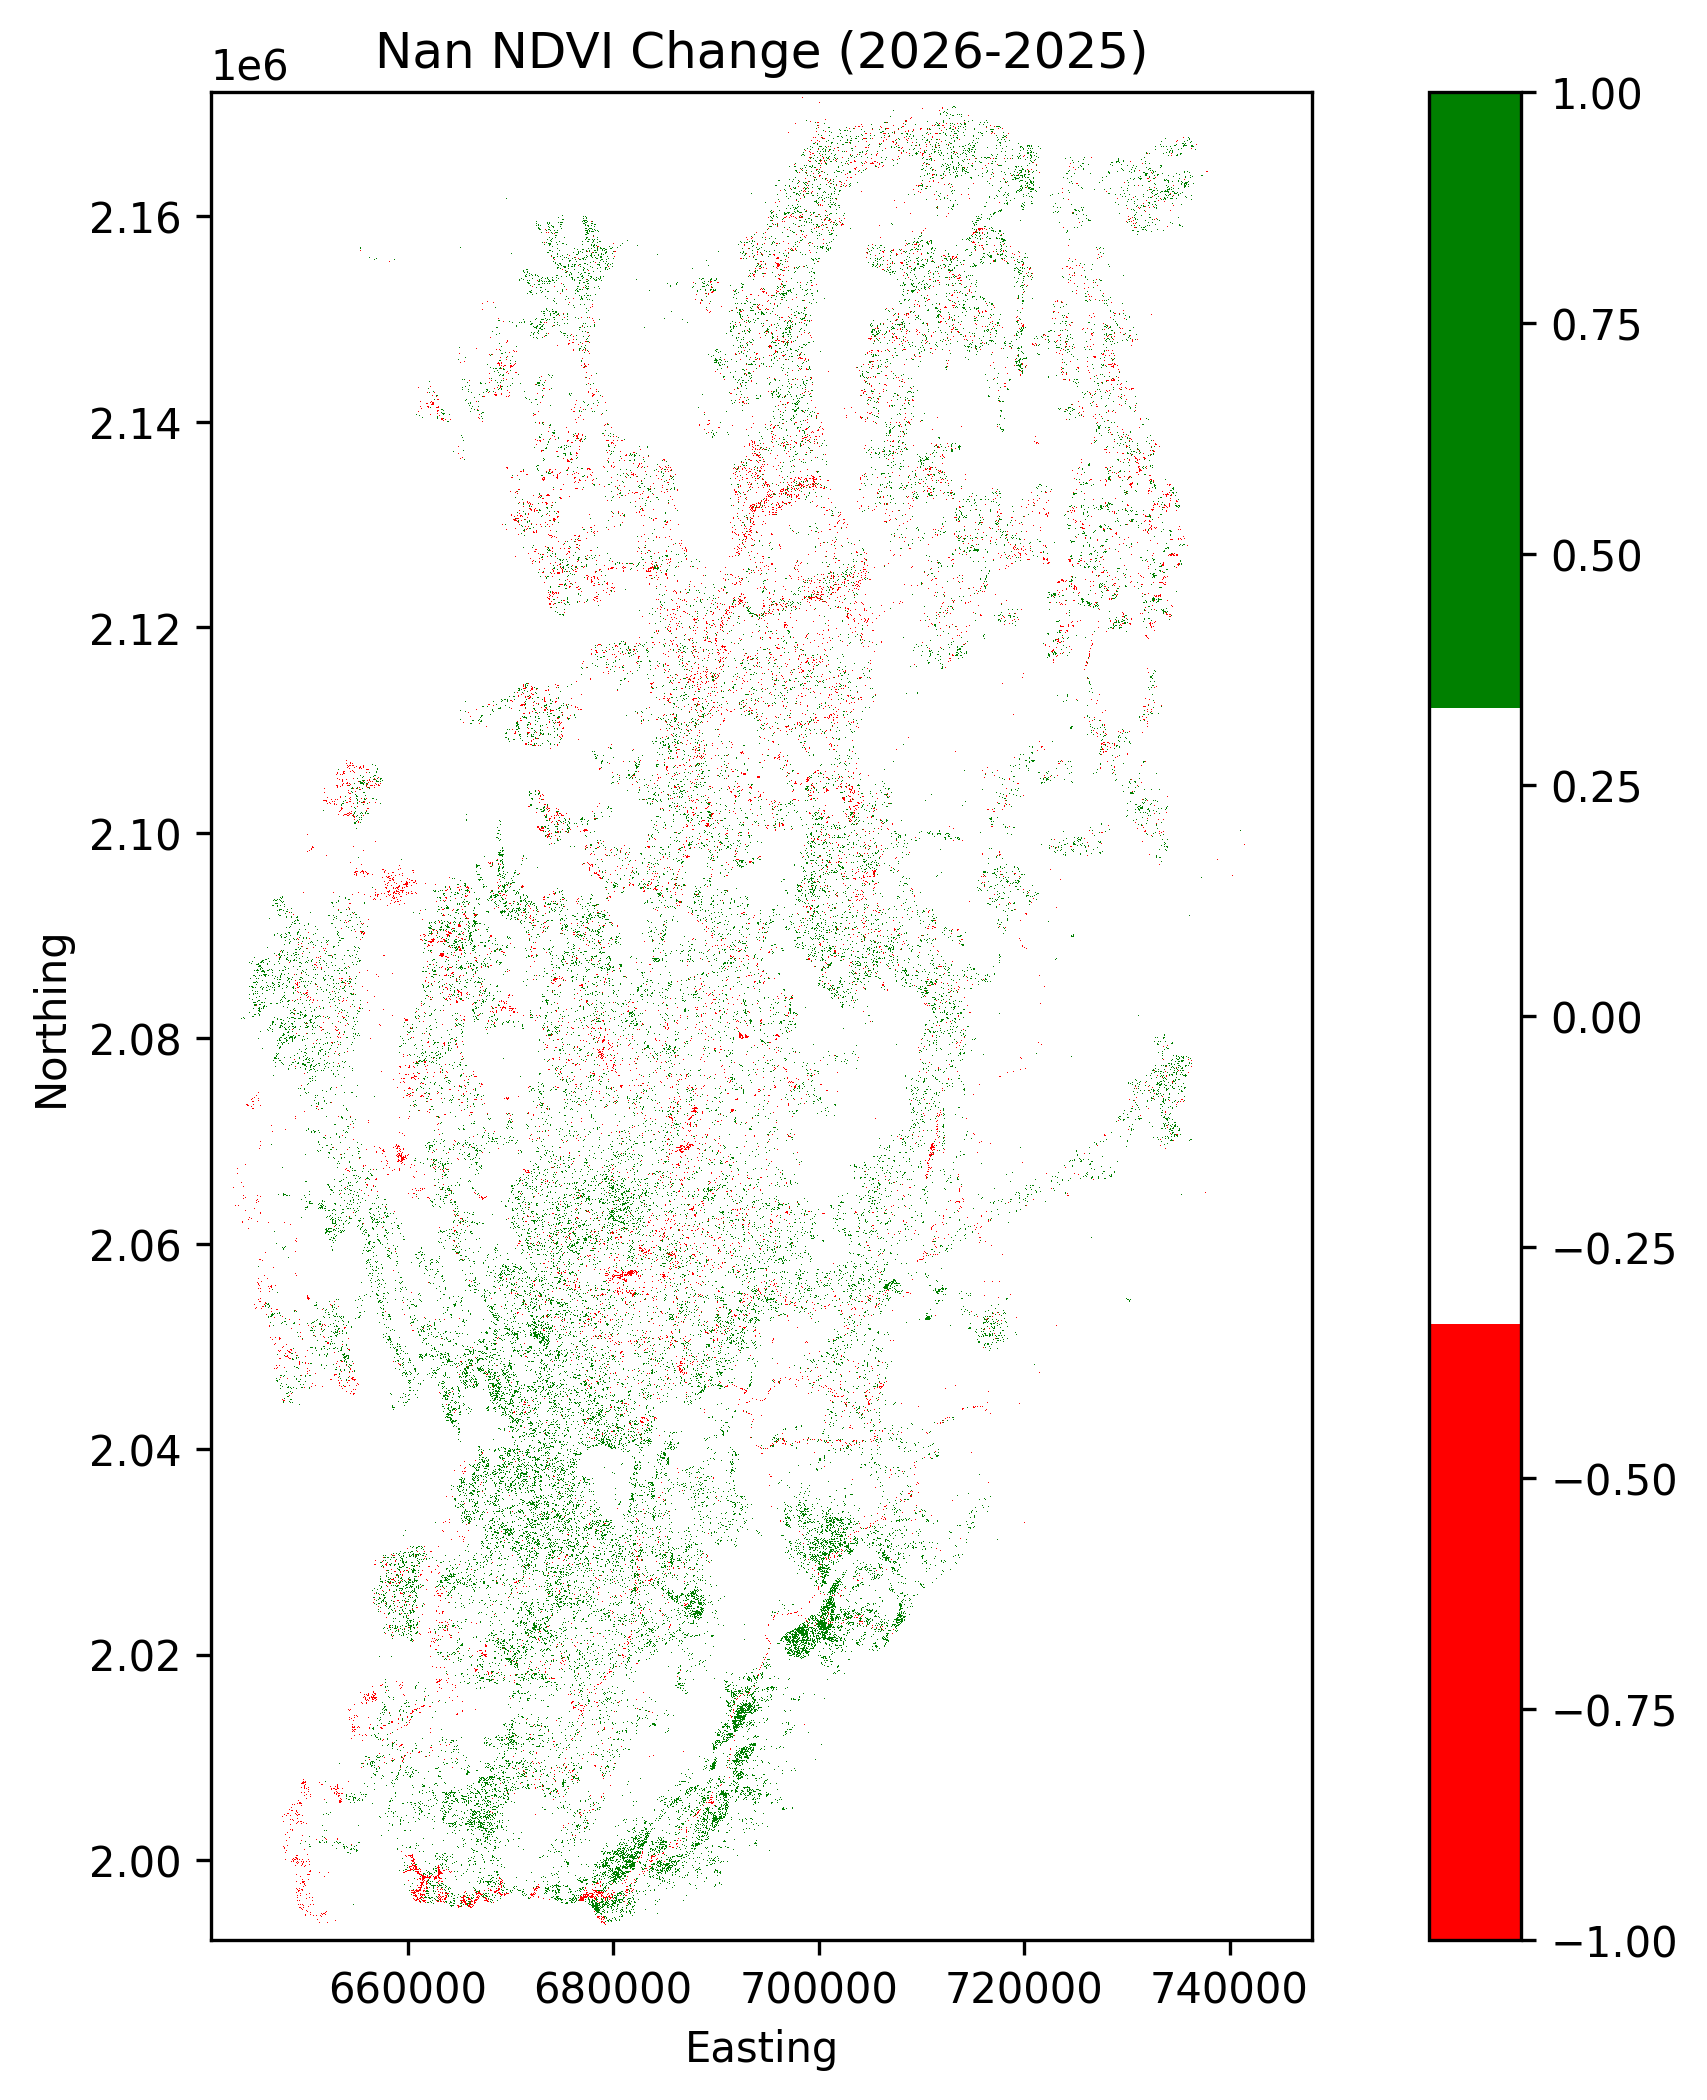

* วิเคราะห์ปัจจัยที่อาจส่งผลกระทบต่อ NDVI เช่น ฤดูกาล การใช้ที่ดิน หรือสภาพภูมิอากาศ

ฤดูกาล และสภาพอากาศ เป็นหนึ่งในปัจจัยที่อาจส่งผลกระทบต่อ NDVI แม้ว่าในการวิเคราะห์จะใช้ภาพ time-series ในช่วงเวลาเดียวกันของทั้ง 2 ปี แต่ความแตกต่างของสภาพอากาศ เช่น ปริมาณน้ำฝน หรือความชื้นอาจทำให้ NDVI แตกต่างกันได้

รูปแบบการใช้ที่ดินส่งผลอย่างมากต่อ NDVI โดยพื้นที่ป่าธรรมชาติจะมี NDVI ที่สูงและคงที่ พื้นที่เกษตรกรรม NDVI จะเปลี่ยนแปลงตามช่วงการปลูกและเก็บเกี่ยว ส่วนพื้นที่เมืองหรือสิ่งปลูกสร้างจะมีค่า NDVI ที่ต่ำ

ไฟป่า และการเผาพื้นที่จะทำให้ NDVI ลดลงอย่างรวดเร็ว หลังจากนั้นหากพืชเริ่มฟื้นตัว NDVI อาจเพิ่มขึ้นในช่วงเวลาต่อมา



**คำถามท้าย Lab**
1. ทำไมการวิเคราะห์ NDVI จากภาพถ่ายดาวเทียมหลายช่วงเวลาจึงมีความสำคัญ?

**คำตอบ** เพราะการวิเคราะห์ NDVI หลายช่วงเวลาช่วยให้เราสามารถติดตามการเปลี่ยนแปลงของพืชพรรณตามช่วงเวลาที่ทำการศึกษาได้อย่างมีประสิทธิภาพ เนื่องจากค่า NDVI สะท้อนถึงความหนาแน่นและสุขภาพของพืชพรรณ เมื่อผนวกกับภาพถ่ายดาวเทียมหลายช่วงเวลาทำให้สามารถระบุแนวโน้มการเพิ่มขึ้นหรือลดลงของพื้นที่ป่า หรือผลกระทบจากภัยธรรมชาติ เช่น ไฟป่า ภัยแล้ง เป็นต้น

2. พื้นที่ที่มีการเปลี่ยนแปลง NDVI อย่างมีนัยสำคัญควรได้รับการตรวจสอบเพิ่มเติมอย่างไร?

**คำตอบ** ควรเปรียบเทียบกับภาพถ่ายดาวเทียมช่วงเวลาอื่นหรือภาพความละเอียดสูง, ตรวจสอบกับแผนที่การใช้ประโยชน์ที่ดิน หรืออาจลงสำรวจพื้นที่จริงเพื่อเก็บข้อมูลภาคสนามซึ่งสามารถช่วยยืนยันว่าการปลี่ยนแปลง NDVI เกิดจากการเปลี่ยนแปลงของพืชพรรณจริง ๆ ไม่ได้มาจากความผิดพลาดของข้อมูล

3. ปัจจัยใดที่อาจทำให้ค่า NDVI เปลี่ยนแปลงโดยไม่เกี่ยวข้องกับการเปลี่ยนแปลงของพืชพรรณ?

**คำตอบ** อาจเกิดได้จากการที่ภาพดาวเทียมไม่ได้ผ่านขั้นตอน Atmospheric Correction ทำให้มีเมฆ หรือเกิด noise ในภาพ, NDVI ไปแสดงความชื้นของดินหรือพื้นผิวแทนที่จะเป็นพืชพรรณ, มีเงาจากภูมิประเทศ เช่น ภูเขาหรือหุบเขา หรือเกิดจาก Internal Error ของดาวเทียมเอง เป็นต้น

4. หากต้องการเพิ่มความแม่นยำของการวิเคราะห์การเปลี่ยนแปลง NDVI ควรใช้เทคนิคอะไรเพิ่มเติม?

**คำตอบ** เพิ่มขั้นตอน Atmospheric Correction หรือใช้ภาพดาวเทียมที่ผ่านการปรับแก้แล้วมาคำนวณ NDVI, ใช้ภาพ time-series หลายช่วง เพื่อติดตามแนวโน้มการเปลี่ยนแปลงระยะยาว, ใช้ดัชนีพืชพรรณอื่นร่วมด้วยในการวิเคราะห์ เช่น Enhanced Vegetation Index (EVI), Soil Adjusted Vegetation Index (SAVI), พิจารณาเลือกใช้ภาพถ่ายดาวเทียมที่มีความละเอียดสูง หรือตรวจสอบกับข้อมูลภาคสนาม เป็นต้น

5. ทำไมการใช้ DEM จึงช่วยให้เข้าใจบริบทของ NDVI ได้ดีขึ้น?

**คำตอบ** เพราะความสูง ความลาดชันของพื้นที่มีผลต่อสภาพแวดล้อม เช่น ปริมาณน้ำ ความชื้น หรือการรับแสงซึ่งส่งผลต่อการเจริญเติบโตของพืชพรรณ ดังนั้นการนำ DEM มาวิเคราะห์ร่วมกับ NDVI ช่วยให้เข้าใจบริบทพื้นที่และสามารถตีความสาเหตุการเปลี่ยนแปลงของ NDVI ได้แม่นยำขึ้น